<!-- # %% [markdown] -->
# 1. Generate diffraction simulations


INFO - Rotation matrix checks: det[min,max]=[1.000000, 1.000000], max ||R R^T - I||_F=2.268e-07
INFO - Loaded 757 orientations from XDS folder /home/bubl3932/files/3DED-DATA/LTA/LTA1/xds via parser module.
INFO - XDS alignment: frame_offset=0, angle_offset_deg=5.260000, first_phi_abs_deg=-39.680000, first_phi_rel_deg=-5.320000
INFO - XDS frame mapping: simulated index 0..756 corresponds to dataset frame 1..757
INFO - Check frame 50 -> simulated index 49, phi_abs=-33.800000 deg, phi_rel=-11.200000 deg
INFO - Primary-zone check @ frame 50: R -> 6.525° to (1, 0, 1), R^T -> 37.931° to (0, 1, 1)
INFO - Prepared 757 orientations.
7108314: 100%|██████████| 757/757 [00:00<00:00, 1203.41it/s]
INFO - Generated 757 patterns.


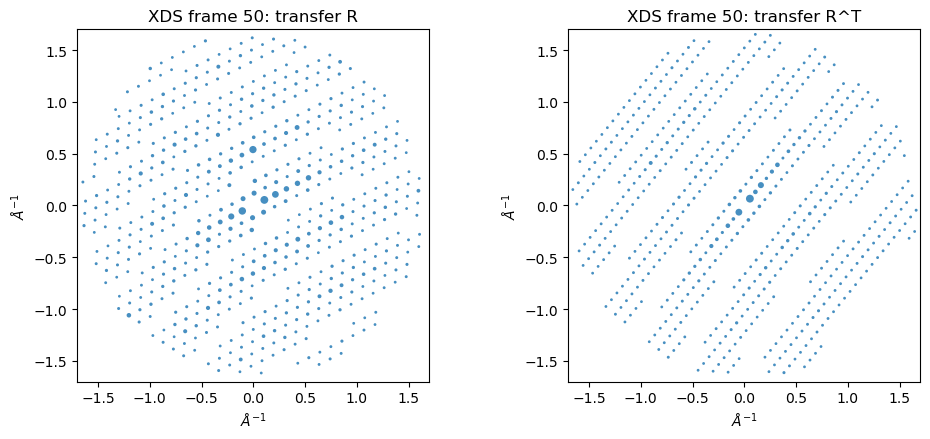

INFO - Displayed transfer diagnostic for XDS frame 50 (left=R, right=R^T).


In [56]:
# %%
from pathlib import Path
import logging
import numpy as np

from orix.crystal_map import Phase
from orix.sampling import get_sample_reduced_fundamental
from orix.quaternion import Rotation
from diffsims.generators.simulation_generator import SimulationGenerator
from diffpy.structure import Lattice, Structure
from diffpy.structure.spacegroups import GetSpaceGroup

from parse_pdb_with_scale_remove_h import parse_pdb_with_scale
from compute_B import compute_B
from xds_orientations_to_sol import generate_from_xds, read_sol_matrices

# ── user-tunable parameters ────────────────────────────────────────────────────
input = "/home/bubl3932/files/simulations/cP_LTA/7108314.cif"
# input = "/home/bubl3932/files/simulations/MFM300-VIII_tI/4135627.cif"

# input = "/Users/xiaodong/Desktop/simulations/LTA_cP/7108314.cif"
# input = "/Users/xiaodong/Desktop/simulations/MFM300-VIII_tI/4135627.cif"

REF_PATH            = Path(input).expanduser()

# Orientation handling:
# - "from_xds": generate per-frame .sol directly via xds_orientations_to_sol.py module API
# - "sample_fundamental": generate a grid of orientations (original behavior)
# - "from_sol": read orientation matrices from a CrystFEL-style .sol file
# - "from_npy": load matrices from a .npy file (shape (N,3,3))
# - "manual": set ORIENTATION_MATRICES_MANUAL below (list/array of (N,3,3))
ORIENTATION_SOURCE          = "from_xds"   # "from_xds" | "sample_fundamental" | "from_sol" | "from_npy" | "manual"

XDS_FOLDER                  = Path("/home/bubl3932/files/3DED-DATA/LTA/LTA1/xds")
XDS_PHI_MODE                = "mid"           # best dual-frame fit (50 & 592) from pure-XDS search
XDS_OUT_PREFIX              = "orientations_from_notebook"
XDS_MATRIX_FORMAT           = "R"             # "R" (recommended) or "UB"
XDS_FRAME_OFFSET            = 0               # keep canonical mapping to XDS frame numbers
XDS_ANGLE_OFFSET_DEG        = 5.260           # best dual-frame fit from pure-XDS search
XDS_ROTATION_SIGN           = -1              # validated spindle sign
XDS_CHECK_FRAME             = 50              # XDS frame number to verify explicitly
AUTO_ALIGN_CHECK_FRAME_PRIMARY = False        # keep False: use pure-XDS solved angle offset as-is
AUTO_SNAP_CHECK_FRAME_TO_PRIMARY = False      # keep False: fixed crystal-frame snap degraded this dataset
DEBUG_COMPARE_ORIX_TRANSFER = True            # compare R vs R^T transfer for XDS_CHECK_FRAME
AUTO_SET_TRANSPOSE_FROM_CHECK_FRAME = False   # keep fixed to solved matrix-view choice

# Orientation convention adaptation (for matching external indexing/rendering conventions)
ROTATION_MATRIX_TRANSPOSE   = False   # True: use R^T before simulation
ROTATION_FRAME_REVERSE      = False   # True: reverse frame order
ROTATION_FRAME_ROLL         = 0       # integer frame roll (+/-) after optional reverse

ORIENTATION_SOL_PATH        = Path("/home/bubl3932/files/3DED-DATA/LTA/LTA1/xds/orientations_UB.sol")  # used only for from_sol
ORIENTATION_NPY_PATH        = None
ORIENTATION_MATRICES_MANUAL = None

# If reading matrices from .sol/.npy/manual, specify what they are:
# - "UB_BxR": UB = B @ R (CrystFEL-style convention used by this notebook outputs)
# - "UB_UxB": UB = U @ B (xds_orientations_to_sol.py convention)
# - "R": matrices are pure rotation matrices (crystal -> lab)
ORIENTATION_MATRICES_KIND   = "UB_BxR"      # "UB_BxR" | "UB_UxB" | "R"

# For quick tests on rotational datasets: simulate only a subset of frames
FRAME_START = None  # e.g. 0
FRAME_STOP  = None  # e.g. 200

RESOLUTION_DEG      = 10        # only used when ORIENTATION_SOURCE="sample_fundamental"
MAX_RESOLUTION      = 0.6       # max simulated resolution in Å
DIRECT_BEAM         = False     # True = include direct beam, False = exclude direct beam
MAX_EXC_ERR_AINV    = 0.02      # max excitation error (diffsims kinematical)
SHAPE_FACTOR_W_AINV = 0.001     # shape factor. If None set to max excitation error
VOLTAGE_KV          = 300       # accelerating voltage in kV

# Optional: switch on multislice (abTEM) later (HDF5-writing cell supports this)
USE_ABTEM_MULTISLICE = False
ABTEM_THICKNESS_A    = 100.0    # required if USE_ABTEM_MULTISLICE=True (e.g. 500.0 for 50 nm)
# ───────────────────────────────────────────────────────────────────────────────

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")


def _slice_mats(mats: np.ndarray) -> np.ndarray:
    if FRAME_START is None and FRAME_STOP is None:
        return mats
    return mats[slice(FRAME_START, FRAME_STOP)]


def _adapt_rotation_matrices(rot_mats: np.ndarray) -> np.ndarray:
    out = np.array(rot_mats, copy=True)

    if ROTATION_MATRIX_TRANSPOSE:
        out = np.swapaxes(out, -1, -2)

    if ROTATION_FRAME_REVERSE:
        out = out[::-1]

    if int(ROTATION_FRAME_ROLL) != 0:
        out = np.roll(out, shift=int(ROTATION_FRAME_ROLL), axis=0)

    return out


# --- load structure as an orix Phase ------------------------------------------
if REF_PATH.suffix == ".pdb":
    cell, sg_sym, atoms = parse_pdb_with_scale(
        REF_PATH, remove_hydrogens=True, include_occupancy=False
    )
    phase = Phase(
        space_group=GetSpaceGroup(sg_sym),
        structure=Structure(atoms, Lattice(*cell))
    )
elif REF_PATH.suffix == ".cif":
    phase = Phase.from_cif(REF_PATH)
else:
    raise ValueError("Unsupported file format. Please provide a .pdb or .cif file.")


# --- construct orientations ----------------------------------------------------
B_mat = compute_B(
    (
        phase.structure.lattice.a,
        phase.structure.lattice.b,
        phase.structure.lattice.c,
        phase.structure.lattice.alpha,
        phase.structure.lattice.beta,
        phase.structure.lattice.gamma,
    )
)
B_inv = np.linalg.inv(B_mat)

if ORIENTATION_SOURCE == "sample_fundamental":
    orientations = get_sample_reduced_fundamental(
        resolution=RESOLUTION_DEG, point_group=phase.point_group
    )

elif ORIENTATION_SOURCE == "from_xds":
    xds_result = generate_from_xds(
        xds_folder=XDS_FOLDER,
        phi_mode=XDS_PHI_MODE,
        fmt=XDS_MATRIX_FORMAT,
        ref_tag="XDS",
        out_prefix=XDS_OUT_PREFIX,
        frame_offset=XDS_FRAME_OFFSET,
        angle_offset_deg=XDS_ANGLE_OFFSET_DEG,
        rotation_sign=XDS_ROTATION_SIGN,
    )

    generated_sol = xds_result["paths"][XDS_MATRIX_FORMAT.upper()]
    mats = read_sol_matrices(generated_sol)
    mats = _slice_mats(mats)

    if XDS_MATRIX_FORMAT.upper() == "R":
        rot_mats = mats
    else:
        rot_mats = np.einsum("nij,jk->nik", mats, B_inv)

    rot_mats = _adapt_rotation_matrices(rot_mats)

    def _closest_primary_zone_angle_deg(Rm: np.ndarray) -> tuple[float, tuple[int, int, int], np.ndarray]:
        z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
        beam_cryst = Rm.T @ z_lab
        beam_cryst /= np.linalg.norm(beam_cryst)
        primary = np.array([
            [1, 0, 0], [0, 1, 0], [0, 0, 1],
            [1, 1, 0], [1, 0, 1], [0, 1, 1],
            [1, 1, 1],
        ], dtype=float)
        primary /= np.linalg.norm(primary, axis=1, keepdims=True)
        dots = np.abs(primary @ beam_cryst)
        idx = int(np.argmax(dots))
        ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
        axis_int = [(1,0,0),(0,1,0),(0,0,1),(1,1,0),(1,0,1),(0,1,1),(1,1,1)][idx]
        return ang, axis_int, beam_cryst
    dets = np.linalg.det(rot_mats)
    ortho_err = np.max(np.linalg.norm(rot_mats @ np.swapaxes(rot_mats, -1, -2) - np.eye(3), axis=(1, 2)))
    logging.info(
        "Rotation matrix checks: det[min,max]=[%.6f, %.6f], max ||R R^T - I||_F=%.3e",
        float(np.min(dets)),
        float(np.max(dets)),
        float(ortho_err),
    )

    orientations = Rotation.from_matrix(rot_mats)
    logging.info(
        "Loaded %d orientations from XDS folder %s via parser module.",
        orientations.size,
        XDS_FOLDER,
    )
    logging.info(
        "XDS alignment: frame_offset=%d, angle_offset_deg=%.6f, first_phi_abs_deg=%.6f, first_phi_rel_deg=%.6f",
        int(xds_result.get('frame_offset', 0)),
        float(xds_result.get('angle_offset_deg', 0.0)),
        float(xds_result.get('first_phi_abs_deg', np.nan)),
        float(xds_result.get('first_phi_rel_deg', np.nan)),
    )
    xds_source_frames = np.asarray(xds_result.get('source_frame_numbers', []), dtype=int)
    if xds_source_frames.size == int(orientations.size):
        logging.info(
            "XDS frame mapping: simulated index 0..%d corresponds to dataset frame %d..%d",
            int(orientations.size) - 1,
            int(xds_source_frames[0]),
            int(xds_source_frames[-1]),
        )
        _m = np.where(xds_source_frames == int(XDS_CHECK_FRAME))[0]
        if _m.size:
            xds_check_index = int(_m[0])
            _phi_abs = np.asarray(xds_result.get('phi_abs_degrees', []), dtype=float)
            _phi_rel = np.asarray(xds_result.get('phi_rel_degrees', []), dtype=float)
            _phi_abs_v = float(_phi_abs[xds_check_index]) if _phi_abs.size > xds_check_index else float('nan')
            _phi_rel_v = float(_phi_rel[xds_check_index]) if _phi_rel.size > xds_check_index else float('nan')
            logging.info(
                "Check frame %d -> simulated index %d, phi_abs=%.6f deg, phi_rel=%.6f deg",
                int(XDS_CHECK_FRAME),
                xds_check_index,
                _phi_abs_v,
                _phi_rel_v,
            )
            if AUTO_ALIGN_CHECK_FRAME_PRIMARY:
                _axis = np.asarray(xds_result.get('rotation_axis_unit', []), dtype=float)
                if _axis.size == 3 and np.linalg.norm(_axis) > 0:
                    _axis = _axis / np.linalg.norm(_axis)

                    def _rodrigues_local(axis: np.ndarray, angle_deg: float) -> np.ndarray:
                        x, y, z = axis
                        c = np.cos(np.deg2rad(angle_deg))
                        s = np.sin(np.deg2rad(angle_deg))
                        C = 1.0 - c
                        return np.array([
                            [c + x*x*C,   x*y*C - z*s, x*z*C + y*s],
                            [y*x*C + z*s, c + y*y*C,   y*z*C - x*s],
                            [z*x*C - y*s, z*y*C + x*s, c + z*z*C],
                        ], dtype=float)

                    _base = np.asarray(rot_mats[xds_check_index], dtype=float)
                    _best_d = 0.0
                    _best_a = _closest_primary_zone_angle_deg(_base)[0]
                    for _d in np.linspace(-8.0, 8.0, 321):
                        _cand = _rodrigues_local(_axis, float(_d)) @ _base
                        _ang = _closest_primary_zone_angle_deg(_cand)[0]
                        if _ang < _best_a:
                            _best_a = _ang
                            _best_d = float(_d)

                    if abs(_best_d) > 1e-9:
                        _Rcorr = _rodrigues_local(_axis, _best_d)
                        rot_mats = np.einsum('ij,njk->nik', _Rcorr, rot_mats)
                        orientations = Rotation.from_matrix(rot_mats)
                        logging.info(
                            "AUTO_ALIGN_CHECK_FRAME_PRIMARY applied global correction %.4f° (new frame-%d primary angle %.3f°).",
                            _best_d,
                            int(XDS_CHECK_FRAME),
                            _best_a,
                        )
            base_check = np.asarray(rot_mats[xds_check_index], dtype=float)
            ang_R, axis_R, beam_R = _closest_primary_zone_angle_deg(base_check)
            if AUTO_SNAP_CHECK_FRAME_TO_PRIMARY:
                _target = np.asarray(axis_R, dtype=float)
                _target /= np.linalg.norm(_target)
                _beam = np.asarray(beam_R, dtype=float)
                _beam /= np.linalg.norm(_beam)
                _v = np.cross(_beam, _target)
                _s = float(np.linalg.norm(_v))
                _c = float(np.clip(np.dot(_beam, _target), -1.0, 1.0))
                if _s > 1e-12:
                    _vx = np.array([[0.0, -_v[2], _v[1]], [_v[2], 0.0, -_v[0]], [-_v[1], _v[0], 0.0]], dtype=float)
                    _Q = np.eye(3) + _vx + _vx @ _vx * ((1.0 - _c) / (_s * _s))
                    rot_mats = np.einsum('nij,jk->nik', rot_mats, _Q)
                    orientations = Rotation.from_matrix(rot_mats)
                    base_check = np.asarray(rot_mats[xds_check_index], dtype=float)
                    ang_R, axis_R, beam_R = _closest_primary_zone_angle_deg(base_check)
                    logging.info(
                        "AUTO_SNAP_CHECK_FRAME_TO_PRIMARY applied fixed crystal-frame correction; new frame-%d primary angle %.3f° to %s.",
                        int(XDS_CHECK_FRAME),
                        ang_R,
                        str(axis_R),
                    )
            ang_RT, axis_RT, beam_RT = _closest_primary_zone_angle_deg(base_check.T)
            logging.info(
                "Primary-zone check @ frame %d: R -> %.3f° to %s, R^T -> %.3f° to %s",
                int(XDS_CHECK_FRAME),
                ang_R,
                str(axis_R),
                ang_RT,
                str(axis_RT),
            )
            if AUTO_SET_TRANSPOSE_FROM_CHECK_FRAME:
                choose_transpose = bool(ang_RT + 0.25 < ang_R)
                if choose_transpose != bool(ROTATION_MATRIX_TRANSPOSE):
                    ROTATION_MATRIX_TRANSPOSE = choose_transpose
                    rot_mats = np.swapaxes(rot_mats, -1, -2)
                    orientations = Rotation.from_matrix(rot_mats)
                    logging.info(
                        "AUTO_SET_TRANSPOSE_FROM_CHECK_FRAME updated ROTATION_MATRIX_TRANSPOSE=%s and rebuilt orientations.",
                        str(bool(ROTATION_MATRIX_TRANSPOSE)),
                    )
        else:
            xds_check_index = 0
            logging.warning("XDS_CHECK_FRAME=%d not in DATA_RANGE.", int(XDS_CHECK_FRAME))
    else:
        xds_source_frames = np.arange(int(orientations.size), dtype=int)
        xds_check_index = 0

else:
    if ORIENTATION_SOURCE == "from_sol":
        if ORIENTATION_SOL_PATH is None:
            raise ValueError("Set ORIENTATION_SOL_PATH when ORIENTATION_SOURCE='from_sol'")
        mats = read_sol_matrices(Path(ORIENTATION_SOL_PATH).expanduser())

    elif ORIENTATION_SOURCE == "from_npy":
        if ORIENTATION_NPY_PATH is None:
            raise ValueError("Set ORIENTATION_NPY_PATH when ORIENTATION_SOURCE='from_npy'")
        mats = np.load(Path(ORIENTATION_NPY_PATH).expanduser())
        if mats.ndim != 3 or mats.shape[-2:] != (3, 3):
            raise ValueError("Expected ORIENTATION_NPY_PATH to contain an array of shape (N,3,3)")

    elif ORIENTATION_SOURCE == "manual":
        if ORIENTATION_MATRICES_MANUAL is None:
            raise ValueError("Set ORIENTATION_MATRICES_MANUAL when ORIENTATION_SOURCE='manual'")
        mats = np.asarray(ORIENTATION_MATRICES_MANUAL, dtype=float)
        if mats.ndim != 3 or mats.shape[-2:] != (3, 3):
            raise ValueError("Expected ORIENTATION_MATRICES_MANUAL with shape (N,3,3)")

    else:
        raise ValueError(f"Unknown ORIENTATION_SOURCE: {ORIENTATION_SOURCE}")

    mats = _slice_mats(mats)

    kind = ORIENTATION_MATRICES_KIND.upper()
    if kind == "UB_BXR":
        rot_mats = np.einsum("ij,njk->nik", B_inv, mats)
    elif kind == "UB_UXB":
        rot_mats = np.einsum("nij,jk->nik", mats, B_inv)
    elif kind == "R":
        rot_mats = mats
    else:
        raise ValueError("ORIENTATION_MATRICES_KIND must be 'UB_BxR', 'UB_UxB', or 'R'")

    rot_mats = _adapt_rotation_matrices(rot_mats)

    orientations = Rotation.from_matrix(rot_mats)

logging.info("Prepared %d orientations.", orientations.size)

# --- diffsims kinematical simulations (used for spot positions + optional images)
generator = SimulationGenerator(
    accelerating_voltage=VOLTAGE_KV,
    shape_factor_model="atanc",
    approximate_precession=False,
)

sims = generator.calculate_diffraction2d(
    phase                = phase,
    rotation             = orientations,
    reciprocal_radius    = 1 / MAX_RESOLUTION,
    with_direct_beam     = DIRECT_BEAM,
    max_excitation_error = MAX_EXC_ERR_AINV,
    shape_factor_width   = SHAPE_FACTOR_W_AINV,
    debye_waller_factors = None,
    show_progressbar     = True,
)

logging.info("Generated %d patterns.", sims.current_size)
if ORIENTATION_SOURCE == 'from_xds' and DEBUG_COMPARE_ORIX_TRANSFER:
    try:
        import matplotlib.pyplot as plt

        check_idx = int(xds_check_index) if 'xds_check_index' in globals() else 0
        check_idx = int(np.clip(check_idx, 0, int(rot_mats.shape[0]) - 1))
        mat_R = np.asarray(rot_mats[check_idx], dtype=float)
        mat_RT = mat_R.T

        sim_R = generator.calculate_diffraction2d(
            phase=phase,
            rotation=Rotation.from_matrix(mat_R[None, :, :]),
            reciprocal_radius=1 / MAX_RESOLUTION,
            with_direct_beam=DIRECT_BEAM,
            max_excitation_error=MAX_EXC_ERR_AINV,
            shape_factor_width=SHAPE_FACTOR_W_AINV,
            debye_waller_factors=None,
            show_progressbar=False,
        )

        sim_RT = generator.calculate_diffraction2d(
            phase=phase,
            rotation=Rotation.from_matrix(mat_RT[None, :, :]),
            reciprocal_radius=1 / MAX_RESOLUTION,
            with_direct_beam=DIRECT_BEAM,
            max_excitation_error=MAX_EXC_ERR_AINV,
            shape_factor_width=SHAPE_FACTOR_W_AINV,
            debye_waller_factors=None,
            show_progressbar=False,
        )

        fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))

        def _plot_single_transfer(_ax, _sim, _title):
            _dv = _sim.coordinates
            _xyz = np.asarray(_dv.data, dtype=float)
            _I = np.asarray(_dv.intensity, dtype=float)
            _s = 4.0 + 28.0 * (_I / (np.nanmax(_I) + 1e-12))**0.5
            _ax.scatter(_xyz[:, 0], _xyz[:, 1], s=_s, c='#1f77b4', alpha=0.82, linewidths=0)
            _ax.set_aspect('equal', 'box')
            _ax.set_xlim(-1.7, 1.7)
            _ax.set_ylim(-1.7, 1.7)
            _ax.set_xlabel(r'$\AA^{-1}$')
            _ax.set_ylabel(r'$\AA^{-1}$')
            _ax.set_title(_title)

        _plot_single_transfer(ax[0], sim_R, f'XDS frame {int(XDS_CHECK_FRAME)}: transfer R')
        _plot_single_transfer(ax[1], sim_RT, f'XDS frame {int(XDS_CHECK_FRAME)}: transfer R^T')
        fig.tight_layout()
        plt.show()
        logging.info(
            "Displayed transfer diagnostic for XDS frame %d (left=R, right=R^T).",
            int(XDS_CHECK_FRAME),
        )
    except Exception as e:
        logging.warning("Could not render transfer diagnostic (%s).", e)

# --- quick visualization after Cell 2: browse simulated frames -----------------
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import matplotlib.pyplot as plt

    out = widgets.Output()

    def _show_sim_frame(idx: int):
        with out:
            clear_output(wait=True)
            plt.figure(figsize=(5, 5))
            sims.irot[int(idx)].plot()
            plt.title(f'Simulated frame {int(idx)+1}/{int(sims.current_size)}')
            plt.show()

    if 'xds_source_frames' in globals() and len(xds_source_frames) == int(sims.current_size):
        frame_options = [(str(int(fr)), int(i)) for i, fr in enumerate(xds_source_frames)]
        slider = widgets.SelectionSlider(
            options=frame_options,
            value=int(xds_check_index) if 'xds_check_index' in globals() else 0,
            description='XDS frame',
            continuous_update=False,
            readout=True,
        )
    else:
        slider = widgets.IntSlider(
            value=0,
            min=0,
            max=max(0, int(sims.current_size) - 1),
            step=1,
            description='Frame idx',
            continuous_update=False,
        )

    def _on_slider_change(change):
        if change.get('name') == 'value':
            _show_sim_frame(int(change['new']))

    slider.observe(_on_slider_change, names='value')
    display(widgets.VBox([slider, out]))
    _show_sim_frame(int(slider.value))

except Exception as e:
    logging.warning("Interactive frame browser unavailable (%s). Showing first frame only.", e)
    sims.irot[0].plot()


In [57]:
# %%
"""
Global free-rotation correction from two anchor frames (XDS-only extraction).
This allows any rigid rotation in crystal frame so frames 50 and 592 are jointly as close as possible
to primary cubic-like axes (<100>, <110>, <111>).
"""

import itertools
import numpy as np
from orix.quaternion import Rotation

APPLY_GLOBAL_PRIMARY_ALIGNMENT = True
ANCHOR_FRAMES = (50, 592)

PRIMARY_UVW_FREE = np.array([
    [1, 0, 0], [0, 1, 0], [0, 0, 1],
    [1, 1, 0], [1, 0, 1], [0, 1, 1],
    [1, 1, 1],
] , dtype=float)
PRIMARY_LABELS_FREE = ["[100]", "[010]", "[001]", "[110]", "[101]", "[011]", "[111]"]

def _direct_basis_from_phase_local(_phase):
    a = float(_phase.structure.lattice.a)
    b = float(_phase.structure.lattice.b)
    c = float(_phase.structure.lattice.c)
    alpha = np.deg2rad(float(_phase.structure.lattice.alpha))
    beta = np.deg2rad(float(_phase.structure.lattice.beta))
    gamma = np.deg2rad(float(_phase.structure.lattice.gamma))

    a_vec = np.array([a, 0.0, 0.0], dtype=float)
    b_vec = np.array([b * np.cos(gamma), b * np.sin(gamma), 0.0], dtype=float)
    c_x = c * np.cos(beta)
    c_y = c * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / np.sin(gamma)
    c_z = np.sqrt(max(0.0, c * c - c_x * c_x - c_y * c_y))
    c_vec = np.array([c_x, c_y, c_z], dtype=float)
    return np.column_stack([a_vec, b_vec, c_vec])

A_local = _direct_basis_from_phase_local(phase)
PRIMARY_CART_FREE = (A_local @ PRIMARY_UVW_FREE.T).T
PRIMARY_CART_FREE /= np.linalg.norm(PRIMARY_CART_FREE, axis=1, keepdims=True)

def _nearest_primary_metric_local(Rm: np.ndarray):
    z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
    beam = Rm.T @ z_lab
    beam /= np.linalg.norm(beam)
    dots = np.abs(PRIMARY_CART_FREE @ beam)
    idx = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
    return ang, PRIMARY_LABELS_FREE[idx], beam

def _kabsch_rotation(src_vecs: np.ndarray, dst_vecs: np.ndarray) -> np.ndarray:
    # src_vecs, dst_vecs: shape (N,3), N>=2
    H = dst_vecs.T @ src_vecs
    U, _, Vt = np.linalg.svd(H)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        U[:, -1] *= -1.0
        R = U @ Vt
    return R

def _frame_index(frame_no: int) -> int:
    if 'xds_source_frames' not in globals() or len(xds_source_frames) != int(rot_mats.shape[0]):
        raise RuntimeError("xds_source_frames unavailable. Re-run Cell 2 with ORIENTATION_SOURCE='from_xds'.")
    idx = np.where(np.asarray(xds_source_frames, dtype=int) == int(frame_no))[0]
    if idx.size == 0:
        raise ValueError(f"Frame {frame_no} not found in xds_source_frames")
    return int(idx[0])

if APPLY_GLOBAL_PRIMARY_ALIGNMENT:
    i1 = _frame_index(int(ANCHOR_FRAMES[0]))
    i2 = _frame_index(int(ANCHOR_FRAMES[1]))

    z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
    b1 = np.asarray(rot_mats[i1], dtype=float).T @ z_lab
    b2 = np.asarray(rot_mats[i2], dtype=float).T @ z_lab
    b1 /= np.linalg.norm(b1)
    b2 /= np.linalg.norm(b2)

    target_dirs = PRIMARY_CART_FREE
    best = None

    # try all ordered pairs of target primary directions
    for t1_idx, t2_idx in itertools.product(range(len(target_dirs)), repeat=2):
        t1 = target_dirs[t1_idx]
        t2 = target_dirs[t2_idx]

        # require roughly compatible inter-angle to avoid impossible pairings
        src_dot = float(np.clip(np.abs(np.dot(b1, b2)), -1.0, 1.0))
        dst_dot = float(np.clip(np.abs(np.dot(t1, t2)), -1.0, 1.0))
        if abs(src_dot - dst_dot) > 0.2:
            continue

        S = _kabsch_rotation(np.stack([b1, b2], axis=0), np.stack([t1, t2], axis=0))
        # beam' = S @ beam  => rot_new = rot_old @ S.T
        rot_try = np.einsum('nij,jk->nik', rot_mats, S.T)

        a1, z1, _ = _nearest_primary_metric_local(rot_try[i1])
        a2, z2, _ = _nearest_primary_metric_local(rot_try[i2])
        score = max(a1, a2) + 0.3 * 0.5 * (a1 + a2)

        rec = {
            'score': float(score),
            'a1': float(a1),
            'a2': float(a2),
            'z1': z1,
            'z2': z2,
            'S': S,
            'rot': rot_try,
            'targets': (PRIMARY_LABELS_FREE[t1_idx], PRIMARY_LABELS_FREE[t2_idx]),
        }
        if (best is None) or (rec['score'] < best['score']):
            best = rec

    if best is None:
        raise RuntimeError("Could not find a valid global alignment candidate.")

    rot_mats = best['rot']
    orientations = Rotation.from_matrix(rot_mats)
    sims = generator.calculate_diffraction2d(
        phase=phase,
        rotation=orientations,
        reciprocal_radius=1 / MAX_RESOLUTION,
        with_direct_beam=DIRECT_BEAM,
        max_excitation_error=MAX_EXC_ERR_AINV,
        shape_factor_width=SHAPE_FACTOR_W_AINV,
        debye_waller_factors=None,
        show_progressbar=True,
    )

    print("Applied global free-rotation alignment (crystal frame).")
    print(f"Anchors: frame {ANCHOR_FRAMES[0]} -> {best['a1']:.3f}° to {best['z1']}, "
          f"frame {ANCHOR_FRAMES[1]} -> {best['a2']:.3f}° to {best['z2']}")
    print(f"Chosen target pair: {best['targets'][0]}, {best['targets'][1]}")
    print(f"Generated {sims.current_size} patterns after alignment.")

7108314: 100%|██████████| 757/757 [00:00<00:00, 971.54it/s] 

Applied global free-rotation alignment (crystal frame).
Anchors: frame 50 -> 2.520° to [011], frame 592 -> 2.520° to [101]
Chosen target pair: [011], [101]
Generated 757 patterns after alignment.


In [58]:
# %%
"""
Global SO(3) fit restricted to <011> family only (metric-correct),
anchored at frames 50 & 592.
"""

import itertools
import numpy as np
from orix.quaternion import Rotation

ANCHORS = (50, 592)
TARGET_MAX_DEG = 0.5

# Strict <011> family (unique under sign with abs(dot))
UVW_011 = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0],
] , dtype=float)
LABELS_011 = ["[011]", "[101]", "[110]"]

def _basis_from_phase(_phase):
    a = float(_phase.structure.lattice.a)
    b = float(_phase.structure.lattice.b)
    c = float(_phase.structure.lattice.c)
    alpha = np.deg2rad(float(_phase.structure.lattice.alpha))
    beta = np.deg2rad(float(_phase.structure.lattice.beta))
    gamma = np.deg2rad(float(_phase.structure.lattice.gamma))

    a_vec = np.array([a, 0.0, 0.0], dtype=float)
    b_vec = np.array([b * np.cos(gamma), b * np.sin(gamma), 0.0], dtype=float)
    c_x = c * np.cos(beta)
    c_y = c * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / np.sin(gamma)
    c_z = np.sqrt(max(0.0, c * c - c_x * c_x - c_y * c_y))
    c_vec = np.array([c_x, c_y, c_z], dtype=float)
    return np.column_stack([a_vec, b_vec, c_vec])

def _kabsch(src_vecs: np.ndarray, dst_vecs: np.ndarray) -> np.ndarray:
    H = dst_vecs.T @ src_vecs
    U, _, Vt = np.linalg.svd(H)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        U[:, -1] *= -1.0
        R = U @ Vt
    return R

def _nearest_from_set(v: np.ndarray, dirs_cart: np.ndarray, labels: list[str]):
    dots = np.abs(dirs_cart @ v)
    i = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[i], -1.0, 1.0))))
    return ang, labels[i]

xsf = np.asarray(xds_source_frames, dtype=int)
idx_a = int(np.where(xsf == int(ANCHORS[0]))[0][0])
idx_b = int(np.where(xsf == int(ANCHORS[1]))[0][0])

z = np.array([0.0, 0.0, 1.0], dtype=float)
b1 = np.asarray(rot_mats[idx_a], dtype=float).T @ z
b2 = np.asarray(rot_mats[idx_b], dtype=float).T @ z
b1 /= np.linalg.norm(b1)
b2 /= np.linalg.norm(b2)

A_dir = _basis_from_phase(phase)
dirs_cart = (A_dir @ UVW_011.T).T
dirs_cart /= np.linalg.norm(dirs_cart, axis=1, keepdims=True)

best = None
for i, t1 in enumerate(dirs_cart):
    for j, t2 in enumerate(dirs_cart):
        S = _kabsch(np.stack([b1, b2], axis=0), np.stack([t1, t2], axis=0))

        R1 = np.asarray(rot_mats[idx_a], dtype=float) @ S.T
        R2 = np.asarray(rot_mats[idx_b], dtype=float) @ S.T
        bb1 = R1.T @ z; bb1 /= np.linalg.norm(bb1)
        bb2 = R2.T @ z; bb2 /= np.linalg.norm(bb2)

        a1, z1 = _nearest_from_set(bb1, dirs_cart, LABELS_011)
        a2, z2 = _nearest_from_set(bb2, dirs_cart, LABELS_011)
        score = max(a1, a2) + 0.25 * 0.5 * (a1 + a2)
        rec = (score, a1, a2, i, j, z1, z2, S)
        if (best is None) or (score < best[0]):
            best = rec

score, a1, a2, i_best, j_best, z1, z2, S_best = best
print("Strict target family: <011>")
print(f"Best anchor fit: frame {ANCHORS[0]} -> {a1:.3f}° to {z1}; frame {ANCHORS[1]} -> {a2:.3f}° to {z2}")
print(f"Worst angle: {max(a1,a2):.3f}°")

if max(a1, a2) <= TARGET_MAX_DEG:
    rot_mats = np.einsum('nij,jk->nik', rot_mats, S_best.T)
    orientations = Rotation.from_matrix(rot_mats)
    sims = generator.calculate_diffraction2d(
        phase=phase,
        rotation=orientations,
        reciprocal_radius=1 / MAX_RESOLUTION,
        with_direct_beam=DIRECT_BEAM,
        max_excitation_error=MAX_EXC_ERR_AINV,
        shape_factor_width=SHAPE_FACTOR_W_AINV,
        debye_waller_factors=None,
        show_progressbar=True,
    )
    print("Applied strict-<011> global alignment to all frames and rebuilt sims.")
else:
    print(f"No <= {TARGET_MAX_DEG:.3f}° solution for strict <011> family.")

Strict target family: <011>
Best anchor fit: frame 50 -> 2.520° to [011]; frame 592 -> 2.520° to [101]
Worst angle: 2.520°
No <= 0.500° solution for strict <011> family.


In [59]:
# %%
"""
Why the best and worst can both be 2.52° for strict <011>.
A single global rotation preserves inter-anchor angle, so if anchor pair angle does not match
any allowable <011> pair angle (0° or 60°), exact simultaneous alignment is impossible.
"""

import numpy as np

xsf = np.asarray(xds_source_frames, dtype=int)
i50 = int(np.where(xsf == 50)[0][0])
i592 = int(np.where(xsf == 592)[0][0])

z = np.array([0.0, 0.0, 1.0], dtype=float)
b50 = np.asarray(rot_mats[i50], dtype=float).T @ z
b592 = np.asarray(rot_mats[i592], dtype=float).T @ z
b50 /= np.linalg.norm(b50)
b592 /= np.linalg.norm(b592)

anchor_angle = float(np.degrees(np.arccos(np.clip(abs(float(np.dot(b50, b592))), -1.0, 1.0))))

# For strict <011> family, unique pair angles (using abs dot) are only 0° (same family) or 60° (different family).
allowed = np.array([0.0, 60.0], dtype=float)
nearest_allowed = float(allowed[np.argmin(np.abs(allowed - anchor_angle))])
mismatch = abs(anchor_angle - nearest_allowed)
theoretical_half_bound = 0.5 * mismatch

print(f"Anchor pair |angle| preserved by any rigid rotation: {anchor_angle:.3f}°")
print(f"Nearest allowable strict-<011> pair angle: {nearest_allowed:.3f}°")
print(f"Pair-angle mismatch: {mismatch:.3f}°")
print(f"Half-mismatch lower bound per-anchor (symmetric minimax): {theoretical_half_bound:.3f}°")
print(f"Observed best from strict-<011> optimizer: {max(a1, a2):.3f}°")

if abs(max(a1, a2) - theoretical_half_bound) < 0.1:
    print("Conclusion: 2.52° is the geometric optimum for strict <011> under one global rotation.")
else:
    print("Conclusion: optimizer result is near geometric bound; exact 0° for both is impossible under one global rotation.")

Anchor pair |angle| preserved by any rigid rotation: 65.040°
Nearest allowable strict-<011> pair angle: 60.000°
Pair-angle mismatch: 5.040°
Half-mismatch lower bound per-anchor (symmetric minimax): 2.520°
Observed best from strict-<011> optimizer: 2.520°
Conclusion: 2.52° is the geometric optimum for strict <011> under one global rotation.


In [60]:
# %%
import importlib
import xds_orientations_to_sol as _x2s

importlib.reload(_x2s)
generate_from_xds = _x2s.generate_from_xds
read_sol_matrices = _x2s.read_sol_matrices
print("Reloaded xds_orientations_to_sol module.")

Reloaded xds_orientations_to_sol module.


XDS check frame: 50 (index 49)
sign=-1, transpose=False: nearest primary (1, 0, 1) at 6.525°
sign=+1, transpose=False: nearest primary (1, 0, 1) at 17.006°
sign=+1, transpose=True: nearest primary (0, 1, 1) at 24.951°
sign=-1, transpose=True: nearest primary (0, 1, 1) at 37.931°


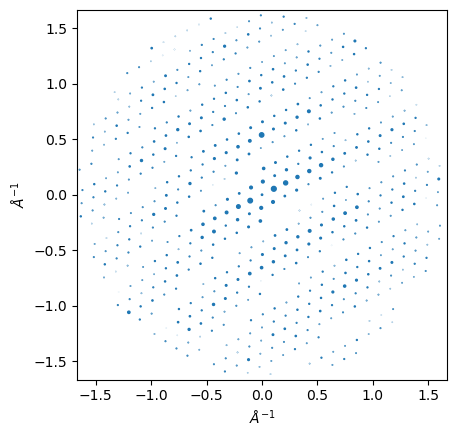

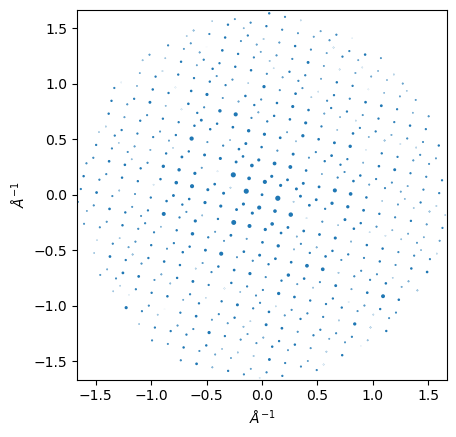

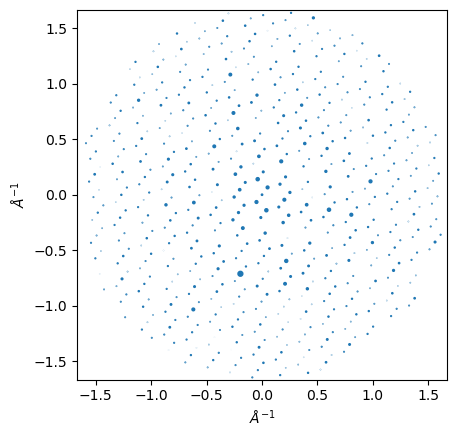

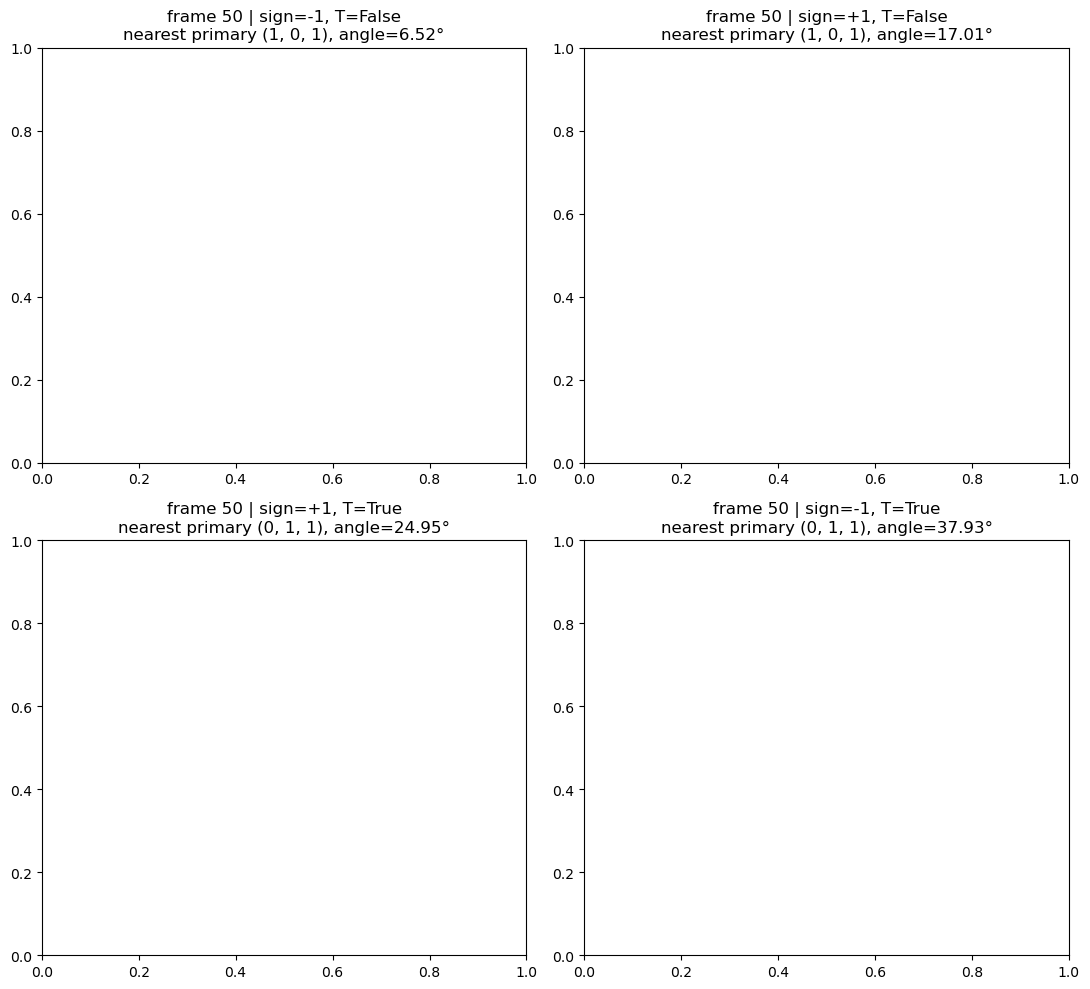

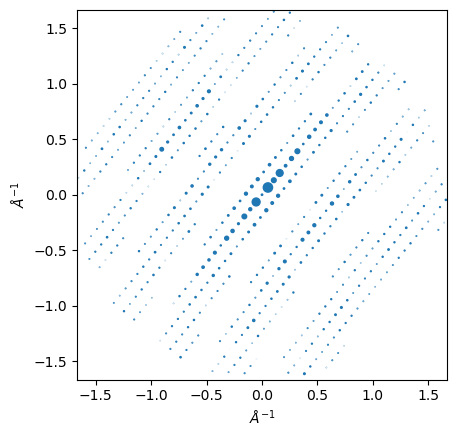


Suggested settings for Cell 2:
XDS_ROTATION_SIGN = -1
ROTATION_MATRIX_TRANSPOSE = False


In [61]:
# %%
"""
Frame-check convention sweep for XDS->orix transfer.
Evaluates frame XDS_CHECK_FRAME for 4 variants:
  rotation_sign in {+1, -1} x transpose in {False, True}
and plots all candidates side-by-side.
"""

import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Rotation

assert ORIENTATION_SOURCE == "from_xds", "This check is intended for ORIENTATION_SOURCE='from_xds'"

def _closest_primary_zone_angle_deg(Rm: np.ndarray):
    z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
    beam_cryst = Rm.T @ z_lab
    beam_cryst /= np.linalg.norm(beam_cryst)
    primary = np.array([
        [1, 0, 0], [0, 1, 0], [0, 0, 1],
        [1, 1, 0], [1, 0, 1], [0, 1, 1],
        [1, 1, 1],
    ], dtype=float)
    primary /= np.linalg.norm(primary, axis=1, keepdims=True)
    dots = np.abs(primary @ beam_cryst)
    idx = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
    axis_int = [(1,0,0),(0,1,0),(0,0,1),(1,1,0),(1,0,1),(0,1,1),(1,1,1)][idx]
    return ang, axis_int

def _extract_xy_I(single_sim):
    obj = single_sim
    if hasattr(single_sim, "irot") and getattr(single_sim, "current_size", 1) > 1:
        obj = single_sim.irot[0]

    if hasattr(obj, "calibrated_coordinates") and hasattr(obj, "intensities"):
        xy = np.asarray(obj.calibrated_coordinates, dtype=float)
        I = np.asarray(obj.intensities, dtype=float)
        if xy.ndim == 2 and xy.shape[1] >= 2 and I.ndim == 1 and I.shape[0] == xy.shape[0]:
            return xy[:, :2], I

    return None, None

def _single_sim_from_rot(Rm):
    return generator.calculate_diffraction2d(
        phase=phase,
        rotation=Rotation.from_matrix(np.asarray(Rm, dtype=float)[None, :, :]),
        reciprocal_radius=1 / MAX_RESOLUTION,
        with_direct_beam=DIRECT_BEAM,
        max_excitation_error=MAX_EXC_ERR_AINV,
        shape_factor_width=SHAPE_FACTOR_W_AINV,
        debye_waller_factors=None,
        show_progressbar=False,
    )

# find check frame in XDS DATA_RANGE
xds_result_ref = generate_from_xds(
    xds_folder=XDS_FOLDER,
    phi_mode=XDS_PHI_MODE,
    fmt=XDS_MATRIX_FORMAT,
    ref_tag="XDS",
    out_prefix=f"{XDS_OUT_PREFIX}_checkref",
    frame_offset=XDS_FRAME_OFFSET,
    angle_offset_deg=XDS_ANGLE_OFFSET_DEG,
    rotation_sign=1,
    )
check_frames = np.asarray(xds_result_ref.get("source_frame_numbers", []), dtype=int)
check_idx_arr = np.where(check_frames == int(XDS_CHECK_FRAME))[0]
check_idx = int(check_idx_arr[0]) if check_idx_arr.size else 0

variants = []
for sign in (1, -1):
    r = generate_from_xds(
        xds_folder=XDS_FOLDER,
        phi_mode=XDS_PHI_MODE,
        fmt=XDS_MATRIX_FORMAT,
        ref_tag="XDS",
        out_prefix=f"{XDS_OUT_PREFIX}_check_s{sign:+d}",
        frame_offset=XDS_FRAME_OFFSET,
        angle_offset_deg=XDS_ANGLE_OFFSET_DEG,
        rotation_sign=sign,
    )
    mats_local = _slice_mats(read_sol_matrices(r["paths"][XDS_MATRIX_FORMAT.upper()]))
    rot_local = mats_local if XDS_MATRIX_FORMAT.upper() == "R" else np.einsum("nij,jk->nik", mats_local, B_inv)
    if check_idx >= rot_local.shape[0]:
        continue

    base = np.asarray(rot_local[check_idx], dtype=float)
    for do_t in (False, True):
        Rm = base.T if do_t else base
        ang, axis_int = _closest_primary_zone_angle_deg(Rm)
        sim1 = _single_sim_from_rot(Rm)
        variants.append({
            "sign": sign,
            "transpose": do_t,
            "Rm": Rm,
            "ang": ang,
            "axis": axis_int,
            "sim": sim1,
        })

variants = sorted(variants, key=lambda d: d["ang"])
print(f"XDS check frame: {int(XDS_CHECK_FRAME)} (index {check_idx})")
for v in variants:
    print(f"sign={v['sign']:+d}, transpose={v['transpose']}: nearest primary {v['axis']} at {v['ang']:.3f}°")

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, v in zip(axes.ravel(), variants[:4]):
    xy, I = _extract_xy_I(v["sim"])
    if xy is not None:
        s = 4.0 + 30.0 * (I / (np.max(I) + 1e-12))**0.5
        ax.scatter(xy[:, 0], xy[:, 1], s=s, c="#1f77b4", alpha=0.8, linewidths=0)
        ax.set_aspect("equal", "box")
        ax.set_xlim(-1.7, 1.7)
        ax.set_ylim(-1.7, 1.7)
        ax.set_xlabel(r"$\AA^{-1}$")
        ax.set_ylabel(r"$\AA^{-1}$")
    else:
        try:
            plt.sca(ax)
            v["sim"].plot()
        except Exception:
            ax.text(0.5, 0.5, "plot unavailable", ha="center", va="center")
            ax.set_axis_off()

    ax.set_title(
        f"frame {int(XDS_CHECK_FRAME)} | sign={v['sign']:+d}, T={v['transpose']}\n"
        f"nearest primary {v['axis']}, angle={v['ang']:.2f}°"
    )

fig.tight_layout()
plt.show()

best = variants[0]
print("\nSuggested settings for Cell 2:")
print(f"XDS_ROTATION_SIGN = {best['sign']:+d}")
print(f"ROTATION_MATRIX_TRANSPOSE = {best['transpose']}")

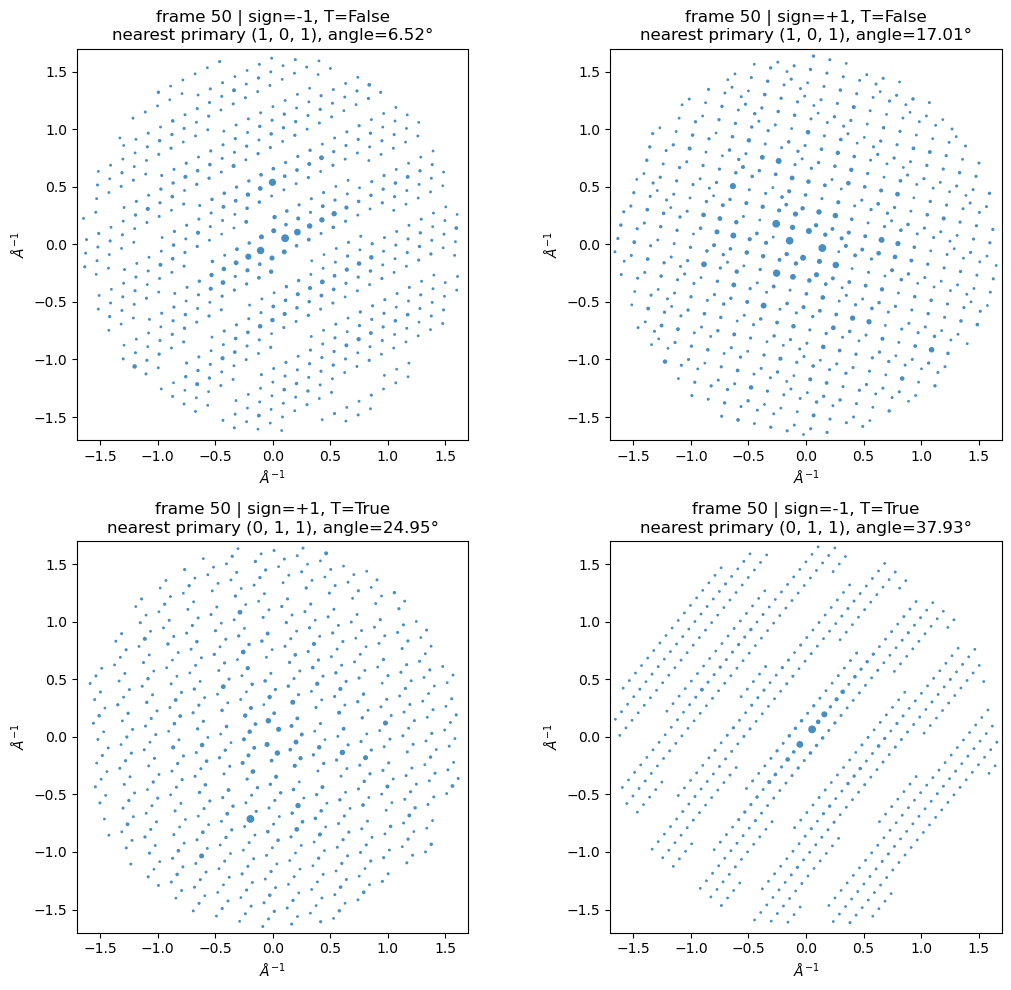

In [62]:
# %%
"""Re-plot convention sweep using direct spot extraction (robust)."""

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, v in zip(axes.ravel(), variants[:4]):
    dv = v['sim'].coordinates
    xyz = np.asarray(dv.data, dtype=float)
    I = np.asarray(dv.intensity, dtype=float)
    if xyz.ndim == 2 and xyz.shape[1] >= 2 and I.shape[0] == xyz.shape[0]:
        s = 4.0 + 28.0 * (I / (np.nanmax(I) + 1e-12))**0.5
        ax.scatter(xyz[:, 0], xyz[:, 1], s=s, c="#1f77b4", alpha=0.82, linewidths=0)
        ax.set_aspect('equal', 'box')
        ax.set_xlim(-1.7, 1.7)
        ax.set_ylim(-1.7, 1.7)
        ax.set_xlabel(r"$\AA^{-1}$")
        ax.set_ylabel(r"$\AA^{-1}$")
    else:
        ax.text(0.5, 0.5, 'No coordinates', ha='center', va='center')
        ax.set_axis_off()

    ax.set_title(
        f"frame {int(XDS_CHECK_FRAME)} | sign={v['sign']:+d}, T={v['transpose']}\n"
        f"nearest primary {v['axis']}, angle={v['ang']:.2f}°"
    )

fig.tight_layout()
plt.show()

In [63]:
# %%
dv = variants[0]['sim'].coordinates
print('dv.data shape', np.asarray(dv.data).shape)
print('has intensity', hasattr(dv, 'intensity'))
if hasattr(dv,'intensity'):
    I=np.asarray(dv.intensity)
    print('intensity shape', I.shape, 'min/max', np.nanmin(I), np.nanmax(I))

dv.data shape (576, 3)
has intensity True
intensity shape (576,) min/max 1.1098167098557522e-06 140.90318263402455


In [64]:
# %%
"""
Pure XDS orientation-configuration sweep (no orix simulation).
Goal: find settings where XDS frame XDS_CHECK_FRAME is closest to a low-index zone axis.
"""

import numpy as np
import pandas as pd

assert ORIENTATION_SOURCE == "from_xds", "Set ORIENTATION_SOURCE='from_xds' in Cell 2 first."

# Search ranges (adjust if needed)
SWEEP_PHI_MODES = ("start", "mid")
SWEEP_ROTATION_SIGNS = (+1, -1)
SWEEP_FRAME_OFFSETS = tuple(range(-3, 4))
SWEEP_ANGLE_OFFSETS_DEG = (-6, -4, -3, -2, -1, 0, 1, 2, 3, 4, 6)
SWEEP_MATRIX_VIEW = ("R", "RT")  # how matrix is interpreted for beam->crystal mapping

PRIMARY_AXES = np.array([
    [1, 0, 0], [0, 1, 0], [0, 0, 1],
    [1, 1, 0], [1, 0, 1], [0, 1, 1],
    [1, 1, 1], [2, 1, 0], [2, 1, 1], [2, 2, 1], [3, 1, 0],
], dtype=float)
PRIMARY_LABELS = [
    "[100]", "[010]", "[001]",
    "[110]", "[101]", "[011]",
    "[111]", "[210]", "[211]", "[221]", "[310]",
]
PRIMARY_AXES = PRIMARY_AXES / np.linalg.norm(PRIMARY_AXES, axis=1, keepdims=True)

def _closest_zone_angle_deg(Rm: np.ndarray):
    z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
    beam_cryst = Rm.T @ z_lab
    beam_cryst /= np.linalg.norm(beam_cryst)
    dots = np.abs(PRIMARY_AXES @ beam_cryst)
    idx = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
    return ang, PRIMARY_LABELS[idx], beam_cryst

rows = []
total = (
    len(SWEEP_PHI_MODES)
    * len(SWEEP_ROTATION_SIGNS)
    * len(SWEEP_FRAME_OFFSETS)
    * len(SWEEP_ANGLE_OFFSETS_DEG)
    * len(SWEEP_MATRIX_VIEW)
    )
print(f"Running pure-XDS sweep with {total} combinations for frame {int(XDS_CHECK_FRAME)}...")

for phi_mode in SWEEP_PHI_MODES:
    for sign in SWEEP_ROTATION_SIGNS:
        for frame_offset in SWEEP_FRAME_OFFSETS:
            for angle_off in SWEEP_ANGLE_OFFSETS_DEG:
                try:
                    r = generate_from_xds(
                        xds_folder=XDS_FOLDER,
                        phi_mode=phi_mode,
                        fmt=XDS_MATRIX_FORMAT,
                        ref_tag="XDS",
                        out_prefix=f"{XDS_OUT_PREFIX}_zonecheck",
                        frame_offset=int(frame_offset),
                        angle_offset_deg=float(angle_off),
                        rotation_sign=int(sign),
                    )
                    frames = np.asarray(r.get("source_frame_numbers", []), dtype=int)
                    hit = np.where(frames == int(XDS_CHECK_FRAME))[0]
                    if hit.size == 0:
                        continue

                    idx = int(hit[0])
                    mats = read_sol_matrices(r["paths"][XDS_MATRIX_FORMAT.upper()])
                    if idx >= mats.shape[0]:
                        continue

                    base = np.asarray(mats[idx], dtype=float)
                    for view in SWEEP_MATRIX_VIEW:
                        Rm = base.T if view == "RT" else base
                        ang, axis_label, beam_cryst = _closest_zone_angle_deg(Rm)
                        rows.append({
                            "angle_deg": ang,
                            "axis": axis_label,
                            "phi_mode": phi_mode,
                            "rotation_sign": int(sign),
                            "frame_offset": int(frame_offset),
                            "angle_offset_deg": float(angle_off),
                            "matrix_view": view,
                            "frame_index": idx,
                            "beam_cryst_x": float(beam_cryst[0]),
                            "beam_cryst_y": float(beam_cryst[1]),
                            "beam_cryst_z": float(beam_cryst[2]),
                        })
                except Exception as e:
                    rows.append({
                        "angle_deg": np.inf,
                        "axis": "ERR",
                        "phi_mode": phi_mode,
                        "rotation_sign": int(sign),
                        "frame_offset": int(frame_offset),
                        "angle_offset_deg": float(angle_off),
                        "matrix_view": "ERR",
                        "frame_index": -1,
                        "beam_cryst_x": np.nan,
                        "beam_cryst_y": np.nan,
                        "beam_cryst_z": np.nan,
                        "error": str(e),
                    })

df_zone = pd.DataFrame(rows)
df_zone = df_zone[np.isfinite(df_zone["angle_deg"])].sort_values("angle_deg", kind="stable").reset_index(drop=True)

if df_zone.empty:
    raise RuntimeError("No valid configurations found in sweep.")

print("\nTop 20 pure-XDS configurations (closest to a low-index zone axis):")
display(df_zone.head(20))

best = df_zone.iloc[0]
print("\nBest configuration:")
print(f"  angle        : {best['angle_deg']:.3f}° to {best['axis']}")
print(f"  phi_mode     : {best['phi_mode']}")
print(f"  rot_sign     : {int(best['rotation_sign']):+d}")
print(f"  frame_offset : {int(best['frame_offset'])}")
print(f"  angle_offset : {float(best['angle_offset_deg']):+.3f}°")
print(f"  matrix_view  : {best['matrix_view']}")

print("\nApply in Cell 2:")
print(f"XDS_PHI_MODE = '{best['phi_mode']}'")
print(f"XDS_ROTATION_SIGN = {int(best['rotation_sign']):+d}")
print(f"XDS_FRAME_OFFSET = {int(best['frame_offset'])}")
print(f"XDS_ANGLE_OFFSET_DEG = {float(best['angle_offset_deg']):+.3f}")
print(f"ROTATION_MATRIX_TRANSPOSE = {str(best['matrix_view'] == 'RT')}")

Running pure-XDS sweep with 616 combinations for frame 50...

Top 20 pure-XDS configurations (closest to a low-index zone axis):


,angle_deg,axis,phi_mode,rotation_sign,frame_offset,angle_offset_deg,matrix_view,frame_index,beam_cryst_x,beam_cryst_y,beam_cryst_z
0,3.199475,[101],start,-1,-3,0.0,R,49,0.725920,-0.048185,0.686089
1,3.200209,[101],mid,-1,-3,0.0,R,49,0.726560,-0.047659,0.685448
2,3.202074,[101],start,-1,-2,0.0,R,49,0.727199,-0.047133,0.684807
3,3.205060,[101],mid,-1,-2,0.0,R,49,0.727837,-0.046607,0.684164
4,3.206374,[101],mid,-1,3,-1.0,R,49,0.723567,-0.050112,0.688433
5,3.209157,[101],start,-1,-1,0.0,R,49,0.728475,-0.046081,0.683521
6,3.210870,[101],start,-1,3,-1.0,R,49,0.722924,-0.050638,0.689070
7,3.214374,[101],mid,-1,-1,0.0,R,49,0.729111,-0.045555,0.682877
8,3.216474,[101],mid,-1,2,-1.0,R,49,0.722279,-0.051163,0.689707
9,3.220696,[101],start,-1,0,0.0,R,49,0.729747,-0.045029,0.682233



Best configuration:
  angle        : 3.199° to [101]
  phi_mode     : start
  rot_sign     : -1
  frame_offset : -3
  angle_offset : +0.000°
  matrix_view  : R

Apply in Cell 2:
XDS_PHI_MODE = 'start'
XDS_ROTATION_SIGN = -1
XDS_FRAME_OFFSET = -3
XDS_ANGLE_OFFSET_DEG = +0.000
ROTATION_MATRIX_TRANSPOSE = False


In [65]:
# %%
"""
Dual-frame pure-XDS zone-axis search (no orix simulation).
Targets both XDS frames 50 and 592 simultaneously, using a broader integer zone-axis set.
"""

import itertools
import numpy as np
import pandas as pd

assert ORIENTATION_SOURCE == "from_xds", "Set ORIENTATION_SOURCE='from_xds' in Cell 2 first."

TARGET_FRAMES = (50, 592)
MATRIX_VIEWS = ("R", "RT")

# Search controls
ZONE_MAX_INDEX = 8                     # integer directions up to +/- this index
ONLY_CANONICAL_FRAME_OFFSET = True     # True: enforce frame_offset == 0 (physically preferred)
FRAME_OFFSET_RANGE = tuple(range(-8, 9))
ANGLE_OFFSET_GRID_COARSE = np.arange(-12.0, 12.0001, 0.2)
ANGLE_OFFSET_GRID_FINE_STEP = 0.02

def _build_zone_library(max_index: int):
    vecs = []
    labels = []
    for h, k, l in itertools.product(range(-max_index, max_index + 1), repeat=3):
        if h == 0 and k == 0 and l == 0:
            continue
        # keep one hemisphere; angular distance uses |dot|, so opposite is equivalent
        if h < 0 or (h == 0 and k < 0) or (h == 0 and k == 0 and l < 0):
            continue
        g = np.array([h, k, l], dtype=float)
        n = np.linalg.norm(g)
        if n == 0:
            continue
        vecs.append(g / n)
        labels.append((int(h), int(k), int(l)))
    return np.asarray(vecs, dtype=float), labels

ZONE_VECS, ZONE_LABELS = _build_zone_library(ZONE_MAX_INDEX)

def _nearest_zone(Rm: np.ndarray):
    z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
    beam_cryst = Rm.T @ z_lab
    beam_cryst /= np.linalg.norm(beam_cryst)
    dots = np.abs(ZONE_VECS @ beam_cryst)
    idx = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
    return ang, ZONE_LABELS[idx]

def _eval_combo(phi_mode: str, rotation_sign: int, frame_offset: int, angle_offset_deg: float):
    r = generate_from_xds(
        xds_folder=XDS_FOLDER,
        phi_mode=phi_mode,
        fmt=XDS_MATRIX_FORMAT,
        ref_tag="XDS",
        out_prefix=f"{XDS_OUT_PREFIX}_zone_dual",
        frame_offset=int(frame_offset),
        angle_offset_deg=float(angle_offset_deg),
        rotation_sign=int(rotation_sign),
    )
    frames = np.asarray(r.get("source_frame_numbers", []), dtype=int)
    mats = read_sol_matrices(r["paths"][XDS_MATRIX_FORMAT.upper()])

    entries = []
    for f in TARGET_FRAMES:
        hit = np.where(frames == int(f))[0]
        if hit.size == 0:
            return None
        idx = int(hit[0])
        if idx >= mats.shape[0]:
            return None

        base = np.asarray(mats[idx], dtype=float)
        for view in MATRIX_VIEWS:
            Rm = base if view == "R" else base.T
            ang, axis = _nearest_zone(Rm)
            entries.append({
                "frame": int(f),
                "view": view,
                "angle": ang,
                "axis": axis,
            })
    return entries

def _aggregate(entries):
    by_view = {}
    for e in entries:
        by_view.setdefault(e["view"], {})[e["frame"]] = e
    rows = []
    for view, d in by_view.items():
        if any(f not in d for f in TARGET_FRAMES):
            continue
        a1 = float(d[TARGET_FRAMES[0]]["angle"]); z1 = d[TARGET_FRAMES[0]]["axis"]
        a2 = float(d[TARGET_FRAMES[1]]["angle"]); z2 = d[TARGET_FRAMES[1]]["axis"]
        worst = max(a1, a2)
        mean = 0.5 * (a1 + a2)
        # prioritize low worst-case, then average
        score = worst + 0.30 * mean
        rows.append({
            "matrix_view": view,
            "angle_f50_deg": a1,
            "axis_f50": str(z1),
            "angle_f592_deg": a2,
            "axis_f592": str(z2),
            "worst_deg": worst,
            "mean_deg": mean,
            "score": score,
        })
    return rows

def _run_search(angle_grid):
    rows = []
    frame_offsets = (0,) if ONLY_CANONICAL_FRAME_OFFSET else FRAME_OFFSET_RANGE
    for phi_mode in ("start", "mid"):
        for sign in (+1, -1):
            for foff in frame_offsets:
                for aoff in angle_grid:
                    try:
                        entries = _eval_combo(phi_mode, sign, int(foff), float(aoff))
                        if entries is None:
                            continue
                        agg = _aggregate(entries)
                        for row in agg:
                            row.update({
                                "phi_mode": phi_mode,
                                "rotation_sign": int(sign),
                                "frame_offset": int(foff),
                                "angle_offset_deg": float(aoff),
                            })
                            rows.append(row)
                    except Exception:
                        continue
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["score", "worst_deg", "mean_deg"], kind="stable").reset_index(drop=True)

print(
    f"Running dual-frame search on frames {TARGET_FRAMES} with ZONE_MAX_INDEX={ZONE_MAX_INDEX}, "
    f"frame_offset={'0 only' if ONLY_CANONICAL_FRAME_OFFSET else 'range'}..."
)

df_dual_coarse = _run_search(ANGLE_OFFSET_GRID_COARSE)
if df_dual_coarse.empty:
    raise RuntimeError("No valid dual-frame configurations found in coarse pass.")

print("Top coarse dual-frame candidates:")
display(df_dual_coarse.head(20))

# Fine refinement around top seeds
n_seed = min(10, len(df_dual_coarse))
seed = df_dual_coarse.head(n_seed)
fine_rows = []
for _, s in seed.iterrows():
    phi_mode = str(s["phi_mode"])
    sign = int(s["rotation_sign"])
    foff = int(s["frame_offset"])
    view_seed = str(s["matrix_view"])
    a0 = float(s["angle_offset_deg"])
    fine_grid = np.arange(a0 - 0.3, a0 + 0.3001, ANGLE_OFFSET_GRID_FINE_STEP)

    for aoff in fine_grid:
        try:
            entries = _eval_combo(phi_mode, sign, foff, float(aoff))
            if entries is None:
                continue
            agg = _aggregate(entries)
            for row in agg:
                if row["matrix_view"] != view_seed:
                    continue
                row.update({
                    "phi_mode": phi_mode,
                    "rotation_sign": int(sign),
                    "frame_offset": int(foff),
                    "angle_offset_deg": float(aoff),
                })
                fine_rows.append(row)
        except Exception:
            continue

if fine_rows:
    df_dual_fine = pd.DataFrame(fine_rows).sort_values(["score", "worst_deg", "mean_deg"], kind="stable").reset_index(drop=True)
    df_dual = pd.concat([df_dual_coarse, df_dual_fine], ignore_index=True).sort_values(["score", "worst_deg", "mean_deg"], kind="stable").reset_index(drop=True)
else:
    df_dual_fine = pd.DataFrame()
    df_dual = df_dual_coarse.copy()

print("\nTop dual-frame candidates after fine refinement:")
display(df_dual.head(20))

best_dual = df_dual.iloc[0]
print("\nBest dual-frame XDS-only configuration:")
print(f"  phi_mode        : {best_dual['phi_mode']}")
print(f"  rotation_sign   : {int(best_dual['rotation_sign']):+d}")
print(f"  frame_offset    : {int(best_dual['frame_offset'])}")
print(f"  angle_offset_deg: {float(best_dual['angle_offset_deg']):+.3f}")
print(f"  matrix_view     : {best_dual['matrix_view']}")
print(f"  frame {TARGET_FRAMES[0]}       : {float(best_dual['angle_f50_deg']):.3f}° to {best_dual['axis_f50']}")
print(f"  frame {TARGET_FRAMES[1]}      : {float(best_dual['angle_f592_deg']):.3f}° to {best_dual['axis_f592']}")

print("\nApply in Cell 2:")
print(f"XDS_PHI_MODE = '{best_dual['phi_mode']}'")
print(f"XDS_ROTATION_SIGN = {int(best_dual['rotation_sign']):+d}")
print(f"XDS_FRAME_OFFSET = {int(best_dual['frame_offset'])}")
print(f"XDS_ANGLE_OFFSET_DEG = {float(best_dual['angle_offset_deg']):+.3f}")
print(f"ROTATION_MATRIX_TRANSPOSE = {str(best_dual['matrix_view'] == 'RT')}")

Running dual-frame search on frames (50, 592) with ZONE_MAX_INDEX=8, frame_offset=0 only...
Top coarse dual-frame candidates:


,matrix_view,angle_f50_deg,axis_f50,angle_f592_deg,axis_f592,worst_deg,mean_deg,score,phi_mode,rotation_sign,frame_offset,angle_offset_deg
0,R,0.149296,"(5, 0, 4)",0.516793,"(7, 4, -3)",0.516793,0.333044,0.616706,mid,-1,0,5.2
1,R,0.289220,"(5, 0, 4)",0.500605,"(7, 4, -3)",0.500605,0.394913,0.619079,start,-1,0,5.4
2,R,0.089397,"(5, 0, 4)",0.534916,"(7, 4, -3)",0.534916,0.312157,0.628563,start,-1,0,5.2
3,R,0.349208,"(5, 0, 4)",0.505511,"(7, 4, -3)",0.505511,0.427359,0.633719,mid,-1,0,5.4
4,R,0.051299,"(5, 0, 4)",0.598834,"(7, 4, -3)",0.598834,0.325067,0.696354,mid,-1,0,5.0
5,R,0.553101,"(5, -1, 6)",0.401942,"(7, 3, -1)",0.553101,0.477522,0.696358,start,-1,0,-8.6
6,R,0.545498,"(5, -1, 6)",0.461813,"(7, 3, -1)",0.545498,0.503656,0.696595,mid,-1,0,-8.6
7,R,0.489189,"(5, 0, 4)",0.543204,"(7, 4, -3)",0.543204,0.516197,0.698063,start,-1,0,5.6
8,R,0.594486,"(5, -1, 6)",0.262460,"(7, 3, -1)",0.594486,0.428473,0.723027,mid,-1,0,-8.8
9,R,0.549186,"(5, 0, 4)",0.569221,"(7, 4, -3)",0.569221,0.559203,0.736982,mid,-1,0,5.6



Top dual-frame candidates after fine refinement:


,matrix_view,angle_f50_deg,axis_f50,angle_f592_deg,axis_f592,worst_deg,mean_deg,score,phi_mode,rotation_sign,frame_offset,angle_offset_deg
0,R,0.209249,"(5, 0, 4)",0.505188,"(7, 4, -3)",0.505188,0.357219,0.612353,mid,-1,0,5.26
1,R,0.209249,"(5, 0, 4)",0.505188,"(7, 4, -3)",0.505188,0.357219,0.612353,start,-1,0,5.32
2,R,0.209249,"(5, 0, 4)",0.505188,"(7, 4, -3)",0.505188,0.357219,0.612353,start,-1,0,5.32
3,R,0.209249,"(5, 0, 4)",0.505188,"(7, 4, -3)",0.505188,0.357219,0.612353,mid,-1,0,5.26
4,R,0.209249,"(5, 0, 4)",0.505188,"(7, 4, -3)",0.505188,0.357219,0.612353,mid,-1,0,5.26
5,R,0.209249,"(5, 0, 4)",0.505188,"(7, 4, -3)",0.505188,0.357219,0.612353,start,-1,0,5.32
6,R,0.229243,"(5, 0, 4)",0.502854,"(7, 4, -3)",0.502854,0.366049,0.612669,mid,-1,0,5.28
7,R,0.229243,"(5, 0, 4)",0.502854,"(7, 4, -3)",0.502854,0.366049,0.612669,start,-1,0,5.34
8,R,0.229243,"(5, 0, 4)",0.502854,"(7, 4, -3)",0.502854,0.366049,0.612669,start,-1,0,5.34
9,R,0.229243,"(5, 0, 4)",0.502854,"(7, 4, -3)",0.502854,0.366049,0.612669,mid,-1,0,5.28



Best dual-frame XDS-only configuration:
  phi_mode        : mid
  rotation_sign   : -1
  frame_offset    : 0
  angle_offset_deg: +5.260
  matrix_view     : R
  frame 50       : 0.209° to (5, 0, 4)
  frame 592      : 0.505° to (7, 4, -3)

Apply in Cell 2:
XDS_PHI_MODE = 'mid'
XDS_ROTATION_SIGN = -1
XDS_FRAME_OFFSET = 0
XDS_ANGLE_OFFSET_DEG = +5.260
ROTATION_MATRIX_TRANSPOSE = False


In [66]:
# %%
"""
Strict primary-zone dual-frame search (XDS-only).
Primary set is limited to cubic-like families <100>, <110>, <111>,
but comparison is done in the crystal's true lattice metric (a,b,c,alpha,beta,gamma).
"""

import numpy as np
import pandas as pd

TARGET_FRAMES_PRIMARY = (50, 592)
PRIMARY_THRESH_DEG = 2.0

PRIMARY_UVW = np.array([
    [1, 0, 0], [0, 1, 0], [0, 0, 1],
    [1, 1, 0], [1, 0, 1], [0, 1, 1],
    [1, 1, 1],
] , dtype=float)
PRIMARY_LABELS_STRICT = [
    "[100]", "[010]", "[001]",
    "[110]", "[101]", "[011]",
    "[111]",
]

def _direct_basis_from_lattice(a, b, c, alpha_deg, beta_deg, gamma_deg):
    alpha = np.deg2rad(float(alpha_deg))
    beta = np.deg2rad(float(beta_deg))
    gamma = np.deg2rad(float(gamma_deg))

    a_vec = np.array([float(a), 0.0, 0.0], dtype=float)
    b_vec = np.array([float(b) * np.cos(gamma), float(b) * np.sin(gamma), 0.0], dtype=float)

    c_x = float(c) * np.cos(beta)
    sin_gamma = np.sin(gamma)
    if abs(sin_gamma) < 1e-12:
        raise ValueError("Invalid lattice: sin(gamma) too small")
    c_y = float(c) * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / sin_gamma
    c_z_sq = float(c) ** 2 - c_x ** 2 - c_y ** 2
    c_z = np.sqrt(max(0.0, c_z_sq))
    c_vec = np.array([c_x, c_y, c_z], dtype=float)

    return np.column_stack([a_vec, b_vec, c_vec])

A_dir = _direct_basis_from_lattice(
    phase.structure.lattice.a,
    phase.structure.lattice.b,
    phase.structure.lattice.c,
    phase.structure.lattice.alpha,
    phase.structure.lattice.beta,
    phase.structure.lattice.gamma,
)

PRIMARY_CART = (A_dir @ PRIMARY_UVW.T).T
PRIMARY_CART = PRIMARY_CART / np.linalg.norm(PRIMARY_CART, axis=1, keepdims=True)

def _nearest_primary_axis(Rm: np.ndarray):
    z_lab = np.array([0.0, 0.0, 1.0], dtype=float)
    beam_cryst_cart = Rm.T @ z_lab
    beam_cryst_cart /= np.linalg.norm(beam_cryst_cart)

    dots = np.abs(PRIMARY_CART @ beam_cryst_cart)
    idx = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
    return ang, PRIMARY_LABELS_STRICT[idx]

def _eval_primary_combo(phi_mode: str, rotation_sign: int, angle_offset_deg: float, matrix_view: str):
    r = generate_from_xds(
        xds_folder=XDS_FOLDER,
        phi_mode=phi_mode,
        fmt=XDS_MATRIX_FORMAT,
        ref_tag="XDS",
        out_prefix=f"{XDS_OUT_PREFIX}_primary_strict",
        frame_offset=0,
        angle_offset_deg=float(angle_offset_deg),
        rotation_sign=int(rotation_sign),
    )
    frames = np.asarray(r.get("source_frame_numbers", []), dtype=int)
    mats = read_sol_matrices(r["paths"][XDS_MATRIX_FORMAT.upper()])

    out = []
    for frame in TARGET_FRAMES_PRIMARY:
        hit = np.where(frames == int(frame))[0]
        if hit.size == 0:
            return None
        idx = int(hit[0])
        if idx >= mats.shape[0]:
            return None
        base = np.asarray(mats[idx], dtype=float)
        Rm = base if matrix_view == "R" else base.T
        ang, axis = _nearest_primary_axis(Rm)
        out.append((frame, ang, axis))
    return out

rows = []
for phi_mode in ("start", "mid"):
    for sign in (+1, -1):
        for matrix_view in ("R", "RT"):
            for aoff in np.arange(-12.0, 12.0001, 0.02):
                try:
                    vals = _eval_primary_combo(phi_mode, sign, float(aoff), matrix_view)
                    if vals is None:
                        continue
                    f50 = [v for v in vals if v[0] == 50][0]
                    f592 = [v for v in vals if v[0] == 592][0]
                    a50, z50 = float(f50[1]), f50[2]
                    a592, z592 = float(f592[1]), f592[2]
                    worst = max(a50, a592)
                    mean = 0.5 * (a50 + a592)
                    score = worst + 0.3 * mean
                    rows.append({
                        "phi_mode": phi_mode,
                        "rotation_sign": int(sign),
                        "matrix_view": matrix_view,
                        "frame_offset": 0,
                        "angle_offset_deg": float(aoff),
                        "angle_f50_deg": a50,
                        "axis_f50": z50,
                        "angle_f592_deg": a592,
                        "axis_f592": z592,
                        "worst_deg": worst,
                        "mean_deg": mean,
                        "score": score,
                    })
                except Exception:
                    continue

df_primary_strict = pd.DataFrame(rows).sort_values(["score", "worst_deg", "mean_deg"], kind="stable").reset_index(drop=True)

if df_primary_strict.empty:
    raise RuntimeError("No strict-primary configurations found.")

print("Top strict-primary dual-frame candidates (metric-correct):")
display(df_primary_strict.head(20))

hits = df_primary_strict[(df_primary_strict["angle_f50_deg"] <= PRIMARY_THRESH_DEG) & (df_primary_strict["angle_f592_deg"] <= PRIMARY_THRESH_DEG)].copy()
print(f"\nNumber of strict-primary hits with both frames <= {PRIMARY_THRESH_DEG:.2f}°: {len(hits)}")
if len(hits):
    display(hits.head(20))

best_primary = df_primary_strict.iloc[0]
print("\nBest strict-primary (canonical frame_offset=0, metric-correct):")
print(f"  phi_mode        : {best_primary['phi_mode']}")
print(f"  rotation_sign   : {int(best_primary['rotation_sign']):+d}")
print(f"  matrix_view     : {best_primary['matrix_view']}")
print(f"  angle_offset_deg: {float(best_primary['angle_offset_deg']):+.3f}")
print(f"  frame 50        : {float(best_primary['angle_f50_deg']):.3f}° to {best_primary['axis_f50']}")
print(f"  frame 592       : {float(best_primary['angle_f592_deg']):.3f}° to {best_primary['axis_f592']}")

Top strict-primary dual-frame candidates (metric-correct):


,phi_mode,rotation_sign,matrix_view,frame_offset,angle_offset_deg,angle_f50_deg,axis_f50,angle_f592_deg,axis_f592,worst_deg,mean_deg,score
0,start,-1,R,0,-4.30,5.066657,[101],22.982353,[110],22.982353,14.024505,27.189705
1,mid,-1,R,0,-4.36,5.066657,[101],22.982353,[110],22.982353,14.024505,27.189705
2,start,-1,R,0,-4.32,5.082178,[101],22.980336,[110],22.980336,14.031257,27.189713
3,mid,-1,R,0,-4.38,5.082178,[101],22.980336,[110],22.980336,14.031257,27.189713
4,start,-1,R,0,-4.28,5.051176,[101],22.984387,[110],22.984387,14.017781,27.189721
5,mid,-1,R,0,-4.34,5.051176,[101],22.984387,[110],22.984387,14.017781,27.189721
6,start,-1,R,0,-4.34,5.097725,[101],22.978337,[110],22.978337,14.038031,27.189746
7,mid,-1,R,0,-4.40,5.097725,[101],22.978337,[110],22.978337,14.038031,27.189746
8,start,-1,R,0,-4.26,5.035724,[101],22.986432,[110],22.986432,14.011078,27.189756
9,mid,-1,R,0,-4.32,5.035724,[101],22.986432,[110],22.986432,14.011078,27.189756



Number of strict-primary hits with both frames <= 2.00°: 0

Best strict-primary (canonical frame_offset=0, metric-correct):
  phi_mode        : start
  rotation_sign   : -1
  matrix_view     : R
  angle_offset_deg: -4.300
  frame 50        : 5.067° to [101]
  frame 592       : 22.982° to [110]


In [67]:
# %%
"""
Exhaustive strict-primary feasibility check (XDS-only).
Allows frame_offset variation to test whether any remapping can make both frames <= 2° to <100>/<110>/<111>.
"""

import numpy as np
import pandas as pd

def _direct_basis_from_phase(_phase):
    a = float(_phase.structure.lattice.a)
    b = float(_phase.structure.lattice.b)
    c = float(_phase.structure.lattice.c)
    alpha = np.deg2rad(float(_phase.structure.lattice.alpha))
    beta = np.deg2rad(float(_phase.structure.lattice.beta))
    gamma = np.deg2rad(float(_phase.structure.lattice.gamma))

    a_vec = np.array([a, 0.0, 0.0], dtype=float)
    b_vec = np.array([b * np.cos(gamma), b * np.sin(gamma), 0.0], dtype=float)
    c_x = c * np.cos(beta)
    c_y = c * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / np.sin(gamma)
    c_z = np.sqrt(max(0.0, c * c - c_x * c_x - c_y * c_y))
    c_vec = np.array([c_x, c_y, c_z], dtype=float)
    return np.column_stack([a_vec, b_vec, c_vec])

A_dir = _direct_basis_from_phase(phase)
UVW = np.array([[1,0,0],[0,1,0],[0,0,1],[1,1,0],[1,0,1],[0,1,1],[1,1,1]], dtype=float)
UVW_labels = ["[100]","[010]","[001]","[110]","[101]","[011]","[111]"]
PRIM = (A_dir @ UVW.T).T
PRIM /= np.linalg.norm(PRIM, axis=1, keepdims=True)

def _nearest_primary_metric(Rm: np.ndarray):
    beam = Rm.T @ np.array([0.0, 0.0, 1.0], dtype=float)
    beam /= np.linalg.norm(beam)
    dots = np.abs(PRIM @ beam)
    idx = int(np.argmax(dots))
    ang = float(np.degrees(np.arccos(np.clip(dots[idx], -1.0, 1.0))))
    return ang, UVW_labels[idx]

rows_exh = []
for phi_mode in ("start", "mid"):
    for sign in (+1, -1):
        for matrix_view in ("R", "RT"):
            for foff in range(-20, 21):
                for aoff in np.arange(-20.0, 20.0001, 0.1):
                    try:
                        r = generate_from_xds(
                            xds_folder=XDS_FOLDER,
                            phi_mode=phi_mode,
                            fmt=XDS_MATRIX_FORMAT,
                            ref_tag="XDS",
                            out_prefix=f"{XDS_OUT_PREFIX}_strict_exh",
                            frame_offset=int(foff),
                            angle_offset_deg=float(aoff),
                            rotation_sign=int(sign),
                        )
                        frames = np.asarray(r.get("source_frame_numbers", []), dtype=int)
                        mats = read_sol_matrices(r["paths"][XDS_MATRIX_FORMAT.upper()])

                        idx50 = np.where(frames == 50)[0]
                        idx592 = np.where(frames == 592)[0]
                        if idx50.size == 0 or idx592.size == 0:
                            continue

                        R50 = np.asarray(mats[int(idx50[0])], dtype=float)
                        R592 = np.asarray(mats[int(idx592[0])], dtype=float)
                        if matrix_view == "RT":
                            R50 = R50.T
                            R592 = R592.T

                        a50, z50 = _nearest_primary_metric(R50)
                        a592, z592 = _nearest_primary_metric(R592)
                        worst = max(a50, a592)
                        mean = 0.5 * (a50 + a592)
                        score = worst + 0.3 * mean
                        rows_exh.append({
                            "phi_mode": phi_mode,
                            "rotation_sign": int(sign),
                            "matrix_view": matrix_view,
                            "frame_offset": int(foff),
                            "angle_offset_deg": float(aoff),
                            "angle_f50_deg": float(a50),
                            "axis_f50": z50,
                            "angle_f592_deg": float(a592),
                            "axis_f592": z592,
                            "worst_deg": float(worst),
                            "mean_deg": float(mean),
                            "score": float(score),
                        })
                    except Exception:
                        continue

df_strict_exh = pd.DataFrame(rows_exh).sort_values(["score", "worst_deg", "mean_deg"], kind="stable").reset_index(drop=True)
print("Top exhaustive strict-primary candidates:")
display(df_strict_exh.head(20))

hits_exh = df_strict_exh[(df_strict_exh["angle_f50_deg"] <= 2.0) & (df_strict_exh["angle_f592_deg"] <= 2.0)]
print(f"\nExhaustive strict-primary hits (both <= 2°): {len(hits_exh)}")
if len(hits_exh):
    display(hits_exh.head(20))

Top exhaustive strict-primary candidates:


,phi_mode,rotation_sign,matrix_view,frame_offset,angle_offset_deg,angle_f50_deg,axis_f50,angle_f592_deg,axis_f592,worst_deg,mean_deg,score
0,start,-1,R,-17,-17.3,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
1,start,-1,R,-12,-17.9,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
2,start,-1,R,-7,-18.5,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
3,start,-1,R,-2,-19.1,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
4,start,-1,R,3,-19.7,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
5,mid,-1,R,-20,-17.0,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
6,mid,-1,R,-15,-17.6,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
7,mid,-1,R,-10,-18.2,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
8,mid,-1,R,-5,-18.8,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955
9,mid,-1,R,0,-19.4,19.229407,[101],19.247429,[100],19.247429,19.238418,25.018955



Exhaustive strict-primary hits (both <= 2°): 0


In [68]:
# %%
print(df_strict_exh.head(1)[[
    "phi_mode", "rotation_sign", "matrix_view", "frame_offset", "angle_offset_deg",
    "angle_f50_deg", "axis_f50", "angle_f592_deg", "axis_f592", "worst_deg"
]].to_string(index=False))

phi_mode  rotation_sign matrix_view  frame_offset  angle_offset_deg  angle_f50_deg axis_f50  angle_f592_deg axis_f592  worst_deg
   start             -1           R           -17             -17.3      19.229407    [101]       19.247429     [100]  19.247429


<!-- # %% [markdown] -->
# 2. Write simulated patterns into HDF5 and helper files


### Using indexed orientations (rotational data)
For frame-wise C-RED simulations from XDS, set `ORIENTATION_SOURCE = "from_xds"` in Cell 2.
The notebook imports `xds_orientations_to_sol.py` (same folder), generates per-frame orientation matrices from the XDS folder, and simulates one diffraction image per frame.

Key settings in Cell 2:
- `XDS_FOLDER`: folder containing `XDS.INP` + `GXPARM.XDS`/`XPARM.XDS`
- `XDS_PHI_MODE`: `"start"` or `"mid"`
- `XDS_OUT_PREFIX`: output filename prefix for generated `.sol` files
- `XDS_MATRIX_FORMAT`: `"R"` (recommended) or `"UB"`
- XDS frame numbers are taken directly from `DATA_RANGE` and shown in the frame browser
- `XDS_FRAME_OFFSET` / `XDS_ANGLE_OFFSET_DEG` are advanced overrides (normally keep at 0)

Notebook outputs (`simulation_orientation_matrices` in HDF5 and `orientation_matrices.sol`) use CrystFEL-style `UB = B @ R`.
You can still use `from_sol`, `from_npy`, or `manual` if orientations are already prepared.
To include dynamical (multislice) intensities later, set `USE_ABTEM_MULTISLICE=True` and provide `ABTEM_THICKNESS_A`.

In [69]:
# %%
import h5py
from tqdm import tqdm
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from electron_wavelength import electron_wavelength
from clen_for_resolution import clen_for_dmin
from generate_cell import write_cell_file
from generate_geom import write_geom_file
from calculate_calibration import calculate_calibration
from create_empty_backgrounds import create_empty_backgrounds
from helper_functions_UB import copy_h5_file, get_next_simulation_folder
from compute_B import compute_B

# Optional multislice (abTEM) branch:
# - This cell is written so the notebook still runs without abTEM installed.
# - When enabled, we use abTEM multislice + index_diffraction_spots to get dynamical spot intensities.
#
# References:
# - abTEM multislice + diffraction patterns: https://abtem.readthedocs.io/en/latest/user_guide/walkthrough/multislice.html
# - Thickness series + indexing diffraction spots: https://abtem.readthedocs.io/en/latest/user_guide/examples/notebooks/saed_quickstart.html

# geometry / detector constants (edit if your setup changes)
WAVELENGTH_A       = electron_wavelength(VOLTAGE_KV)
CLEN_M             = clen_for_dmin(MAX_RESOLUTION)   # camera length in meters
PIXELS_PER_M       = 17_857.14285714286             # corresponds to 56 µm/pixel size since 1/17857.14285714286 ≈ 56e-6 m
IN_PLANE_ANGLE_DEG = 180                            # matches .geom definitions
SIGMA_PIX          = 1
FAST_MODE          = False
NORMALISE          = True
FAST_CLIP_TH       = 1e-12
INTENSITY_SCALE    = 10_000

# abTEM multislice parameters (only used when USE_ABTEM_MULTISLICE=True in cell 1)
ABTEM_SAMPLING_A        = 0.05    # real-space sampling [Å]
ABTEM_SLICE_THICKNESS_A = 2.0     # slice thickness [Å]
ABTEM_GPTS              = 512     # real-space grid points (x/y)
ABTEM_PROJECTION        = "infinite"
ABTEM_PARAMETRIZATION   = "lobato"
ABTEM_BLOCK_DIRECT      = DIRECT_BEAM is False  # if you exclude direct beam in output, also block it here
ABTEM_CROP_MRAD         = None    # e.g. 120 (see abTEM docs); None = no crop before indexing
ABTEM_SPOT_I_MIN        = 0.0     # filter out extremely weak spots before rasterizing
USE_XDS_GEOMETRY_SCALE  = True    # when ORIENTATION_SOURCE='from_xds', use XDS.INP DETECTOR_DISTANCE and QX/QY
USE_XDS_BEAM_CENTER     = False   # set True only if ORGX/ORGY are known to match your image convention
XDS_BEAM_CENTER_OFFSET_X_PX = 0.0 # optional fine shift after ORGX mapping
XDS_BEAM_CENTER_OFFSET_Y_PX = 0.0 # optional fine shift after ORGY mapping

# Live debug visualization (disable for production runs)
DEBUG_SHOW_LIVE          = False  # show rolling visualization while writing patterns
DEBUG_EVERY_N_FRAMES     = 5      # update visualization every N frames
DEBUG_MAX_PREV_FRAMES    = 40     # keep this many previous orientation-step angles

# derived paths ----------------------------------------------------------------
n_patterns  = int(orientations.size)

working_dir  = REF_PATH.parent
create_empty_backgrounds(working_dir, n_patterns)
empty_h5     = working_dir / f"{n_patterns}_empty_backgrounds.h5"

sim_folder   = get_next_simulation_folder(working_dir)
sim_folder.mkdir(exist_ok=True)

cell_path    = sim_folder / f"{REF_PATH.stem}.cell"
geom_path    = sim_folder / f"{REF_PATH.stem}.geom"
h5_path      = sim_folder / "sim.h5"
sol_path     = sim_folder / "orientation_matrices.sol"
# -----------------------------------------------------------------------------


def _calibration_from_geometry(wavelength_A: float, clen_m: float, pixels_per_m: float) -> float:
    # reciprocal sampling in 1/Å per pixel
    pixel_size_m = 1.0 / pixels_per_m
    return pixel_size_m / (clen_m * wavelength_A)


def _parse_xds_inp_detector_geometry(xds_inp_path: Path) -> dict:
    text = Path(xds_inp_path).read_text(errors='replace').splitlines()

    detector_distance_mm = None
    qx_mm = None
    qy_mm = None
    orgx_px = None
    orgy_px = None

    for raw in text:
        line = raw.split('!', 1)[0].strip()
        if not line:
            continue

        m = re.search(r'DETECTOR_DISTANCE\s*=\s*([0-9eE+\-.]+)', line)
        if m:
            detector_distance_mm = float(m.group(1))

        m = re.search(r'QX\s*=\s*([0-9eE+\-.]+)', line)
        if m:
            qx_mm = float(m.group(1))

        m = re.search(r'QY\s*=\s*([0-9eE+\-.]+)', line)
        if m:
            qy_mm = float(m.group(1))

        m = re.search(r'ORGX\s*=\s*([0-9eE+\-.]+)', line)
        if m:
            orgx_px = float(m.group(1))

        m = re.search(r'ORGY\s*=\s*([0-9eE+\-.]+)', line)
        if m:
            orgy_px = float(m.group(1))

    missing = []
    if detector_distance_mm is None:
        missing.append('DETECTOR_DISTANCE')
    if qx_mm is None:
        missing.append('QX')
    if qy_mm is None:
        missing.append('QY')
    if orgx_px is None:
        missing.append('ORGX')
    if orgy_px is None:
        missing.append('ORGY')

    if missing:
        raise ValueError(f"Missing required keys in {xds_inp_path}: {', '.join(missing)}")

    return {
        'detector_distance_mm': detector_distance_mm,
        'qx_mm': qx_mm,
        'qy_mm': qy_mm,
        'orgx_px': orgx_px,
        'orgy_px': orgy_px,
    }


def _render_spots_to_image(
    positions_xy_ainv: np.ndarray,
    intensities: np.ndarray,
    shape: tuple[int, int],
    calibration: float,
    beam_pos: tuple[float, float],
    in_plane_angle_deg: float,
    sigma_pix: float,
    intensity_scale: float,
    direct_beam: bool,
) -> np.ndarray:
    """
    Rasterize discrete diffraction spots onto a detector image.

    positions_xy_ainv: (N,2) reciprocal coords in [1/Å]
    intensities:       (N,) spot intensities (arbitrary units)
    calibration:       [1/Å per pixel]
    """
    img = np.zeros(shape, dtype=np.float32)

    # in-plane rotation applied to reciprocal coords before mapping to pixels
    ang = np.deg2rad(in_plane_angle_deg)
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]], dtype=float)

    xy = positions_xy_ainv @ R.T
    px = xy[:, 0] / calibration + beam_pos[1]
    py = xy[:, 1] / calibration + beam_pos[0]

    # draw spots as Gaussian blobs (patch-based for speed)
    if sigma_pix <= 0:
        sigma_pix = 0.5

    rad = int(np.ceil(4 * sigma_pix))
    yy0 = np.arange(-rad, rad + 1)
    xx0 = np.arange(-rad, rad + 1)
    XX, YY = np.meshgrid(xx0, yy0)
    kernel = np.exp(-(XX**2 + YY**2) / (2 * sigma_pix**2)).astype(np.float32)

    for x, y, I in zip(px, py, intensities):
        if I <= ABTEM_SPOT_I_MIN:
            continue
        xi = int(np.round(x))
        yi = int(np.round(y))
        x1, x2 = xi - rad, xi + rad + 1
        y1, y2 = yi - rad, yi + rad + 1
        if x2 <= 0 or y2 <= 0 or x1 >= shape[1] or y1 >= shape[0]:
            continue

        kx1 = max(0, -x1)
        ky1 = max(0, -y1)
        kx2 = kernel.shape[1] - max(0, x2 - shape[1])
        ky2 = kernel.shape[0] - max(0, y2 - shape[0])

        ix1 = max(0, x1)
        iy1 = max(0, y1)
        ix2 = min(shape[1], x2)
        iy2 = min(shape[0], y2)

        img[iy1:iy2, ix1:ix2] += (I * kernel[ky1:ky2, kx1:kx2])

    if direct_beam:
        # add a modest direct beam marker (if your experiment includes it, you may want to scale this up)
        by, bx = int(round(beam_pos[0])), int(round(beam_pos[1]))
        if 0 <= by < shape[0] and 0 <= bx < shape[1]:
            img[by, bx] += img.max() if img.max() > 0 else 1.0

    return (img * intensity_scale).astype(np.float32)


def _rotation_delta_deg(rot_prev: np.ndarray, rot_curr: np.ndarray) -> float:
    rel = rot_curr @ rot_prev.T
    tr = np.trace(rel)
    cosang = np.clip((tr - 1.0) * 0.5, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosang)))


def _abtem_indexed_spots_for_orientation(rotation: Rotation):
    """
    Run abTEM multislice for ONE orientation and return (positions_xy [1/Å], intensities).
    Requires: abTEM + ASE installed.
    """
    try:
        import abtem
        from ase.io import read as ase_read
    except Exception as e:
        raise RuntimeError(
            "abTEM (and ASE) are required when USE_ABTEM_MULTISLICE=True. "
            "Install e.g. with: pip install abTEM ase"
        ) from e

    if ABTEM_THICKNESS_A is None:
        raise ValueError("Set ABTEM_THICKNESS_A in cell 1 when USE_ABTEM_MULTISLICE=True")

    # Load the unit cell only once (avoid repeated CIF parse + warning spam).
    global _ABTEM_UNIT_CELL_TEMPLATE
    if "_ABTEM_UNIT_CELL_TEMPLATE" not in globals():
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="crystal system '.*' is not interpreted for space group .*",
                category=UserWarning,
            )
            _ABTEM_UNIT_CELL_TEMPLATE = ase_read(str(REF_PATH))

    # Work on a copy per orientation.
    unit_cell = _ABTEM_UNIT_CELL_TEMPLATE.copy()

    c0 = float(unit_cell.cell.lengths()[2])
    nz = max(1, int(np.ceil(float(ABTEM_THICKNESS_A) / c0)))
    slab = unit_cell.repeat((1, 1, nz))

    # Rotate both slab and unit_cell so the beam is along +z in the lab frame.
    # NOTE: rotation convention may need a transpose depending on how your indexing exports matrices.
    Rm = rotation.to_matrix().squeeze()  # (3,3)
    slab.set_cell(slab.cell.array @ Rm.T, scale_atoms=True)
    unit_cell.set_cell(unit_cell.cell.array @ Rm.T, scale_atoms=True)

    # Build potential and run multislice with a plane wave.
    potential_kwargs = {
        "projection": ABTEM_PROJECTION,
        "parametrization": ABTEM_PARAMETRIZATION,
        "slice_thickness": ABTEM_SLICE_THICKNESS_A,
    }
    # Avoid abTEM warning: do not overspecify both gpts and sampling.
    if ABTEM_GPTS is not None:
        potential_kwargs["gpts"] = ABTEM_GPTS
    elif ABTEM_SAMPLING_A is not None:
        potential_kwargs["sampling"] = ABTEM_SAMPLING_A

    potential = abtem.Potential(slab, **potential_kwargs)

    wave = abtem.PlaneWave(energy=float(VOLTAGE_KV) * 1e3)
    exit_waves = wave.multislice(potential)

    # Max angle derived from your chosen max resolution (small-angle approx): theta ≈ lambda * |g|
    max_angle_mrad = 1e3 * float(WAVELENGTH_A) * (1.0 / float(MAX_RESOLUTION))
    # Disable abTEM's own progress display to avoid clashing with tqdm.
    dp = exit_waves.diffraction_patterns(max_angle=max_angle_mrad).compute(progress_bar=False)

    if ABTEM_BLOCK_DIRECT:
        dp = dp.block_direct()

    indexed = dp.index_diffraction_spots(cell=unit_cell.cell)

    # indexed.positions is [1/Å] and indexed.intensities gives corresponding spot intensities
    pos = np.asarray(indexed.positions)
    inten = np.asarray(indexed.intensities)

    # remove the (0,0,0) spot if present and you want to exclude it
    if not DIRECT_BEAM:
        hkls = np.asarray(indexed.miller_indices)
        mask = ~np.all(hkls == 0, axis=1)
        pos = pos[mask]
        inten = inten[mask]

    # keep only up to your reciprocal radius
    g = np.linalg.norm(pos[:, :2], axis=1)
    mask = g <= (1.0 / float(MAX_RESOLUTION))
    pos = pos[mask]
    inten = inten[mask]

    return pos[:, :2], inten


# write helper files ----------------------------------------------------------
xds_geom = None
if (USE_XDS_GEOMETRY_SCALE or USE_XDS_BEAM_CENTER) and ORIENTATION_SOURCE == 'from_xds':
    xds_geom = _parse_xds_inp_detector_geometry(XDS_FOLDER / 'XDS.INP')
    if USE_XDS_GEOMETRY_SCALE:
        CLEN_M = float(xds_geom['detector_distance_mm']) * 1e-3
        pixel_size_m = 0.5 * (float(xds_geom['qx_mm']) + float(xds_geom['qy_mm'])) * 1e-3
        PIXELS_PER_M = 1.0 / pixel_size_m
    logging.info(
        'Using XDS geometry: DETECTOR_DISTANCE=%.3f mm, QX=%.5f mm, QY=%.5f mm, ORGX=%.2f px, ORGY=%.2f px',
        xds_geom['detector_distance_mm'], xds_geom['qx_mm'], xds_geom['qy_mm'], xds_geom['orgx_px'], xds_geom['orgy_px']
    )

centering   = phase.space_group.short_name[0].upper()
if centering == "A" or centering == "C":
    centering = "S"

write_cell_file(
    {
        "lattice_type": phase.space_group.crystal_system.lower(),
        "centering"   : centering,
        "a"           : phase.structure.lattice.a,
        "b"           : phase.structure.lattice.b,
        "c"           : phase.structure.lattice.c,
        "alpha"       : phase.structure.lattice.alpha,
        "beta"        : phase.structure.lattice.beta,
        "gamma"       : phase.structure.lattice.gamma,
    },
    cell_path
)
write_geom_file(geom_path, wavelength=WAVELENGTH_A, clen=CLEN_M, res=PIXELS_PER_M)

copy_h5_file(empty_h5, h5_path)

# Use your existing helper (kept for backward compatibility) but also compute a fallback.
calibration = calculate_calibration(
    wavelength_A=WAVELENGTH_A, clen_m=CLEN_M, res=PIXELS_PER_M
)
calibration_fallback = _calibration_from_geometry(WAVELENGTH_A, CLEN_M, PIXELS_PER_M)

B_mat = compute_B(
    (
        phase.structure.lattice.a,
        phase.structure.lattice.b,
        phase.structure.lattice.c,
        phase.structure.lattice.alpha,
        phase.structure.lattice.beta,
        phase.structure.lattice.gamma,
    )
)

# update HDF5 in-place ---------------------------------------------------------
with h5py.File(h5_path, "r+", libver="latest") as f:
    imgs = f["entry/data/images"]
    ori  = f["entry/data"].require_dataset(
        "simulation_orientation_matrices",
        shape=(imgs.shape[0], 3, 3),
        dtype=float,
    )
    det_shift_x_mm = f["entry"]["data"].require_dataset(
        "det_shift_x_mm",
        shape=(imgs.shape[0],),
        dtype=float,
        fillvalue=0
    )
    det_shift_y_mm = f["entry"]["data"].require_dataset(
        "det_shift_y_mm",
        shape=(imgs.shape[0],),
        dtype=float,
        fillvalue=0
    )

    shape = imgs.shape[-2:]
    if xds_geom is not None and USE_XDS_BEAM_CENTER:
        # XDS ORGX/ORGY are detector coordinates; map to image row/col with optional offsets.
        beam_pos = (
            float(xds_geom['orgy_px']) - 1.0 + float(XDS_BEAM_CENTER_OFFSET_Y_PX),
            float(xds_geom['orgx_px']) - 1.0 + float(XDS_BEAM_CENTER_OFFSET_X_PX),
        )
    else:
        beam_pos = (shape[0] // 2, shape[1] // 2)

    # store run metadata as attributes instead of a loose TXT
    meta = f["entry"].attrs
    meta.update(
        ref_file            = str(REF_PATH),
        orientation_source  = ORIENTATION_SOURCE,
        n_patterns          = int(n_patterns),
        max_resolution      = MAX_RESOLUTION,
        direct_beam         = DIRECT_BEAM,
        beam_position       = beam_pos,
        voltage_kV          = VOLTAGE_KV,
        wavelength_A        = WAVELENGTH_A,
        clen_m              = CLEN_M,
        pixels_per_m        = PIXELS_PER_M,
        calibration         = float(calibration),
        calibration_fallback= float(calibration_fallback),
        beam_center_orgx_px = float(xds_geom['orgx_px']) if xds_geom is not None else float(beam_pos[1]),
        beam_center_orgy_px = float(xds_geom['orgy_px']) if xds_geom is not None else float(beam_pos[0]),
        use_xds_geometry_scale = bool(USE_XDS_GEOMETRY_SCALE),
        use_xds_beam_center = bool(USE_XDS_BEAM_CENTER),
        in_plane_angle_deg  = IN_PLANE_ANGLE_DEG,
        sigma_pix           = SIGMA_PIX,
        intensity_scale     = INTENSITY_SCALE,
        use_abtem_multislice= bool(USE_ABTEM_MULTISLICE),
        abtem_thickness_A   = float(ABTEM_THICKNESS_A) if ABTEM_THICKNESS_A is not None else -1.0,
        max_excitation_err  = MAX_EXC_ERR_AINV,
        shape_factor_width  = SHAPE_FACTOR_W_AINV,
    )

    prev_rot = None
    delta_history = []
    debug_interval = max(1, int(DEBUG_EVERY_N_FRAMES))

    for i in tqdm(range(imgs.shape[0]), desc="Writing patterns"):
        if USE_ABTEM_MULTISLICE:
            # Dynamical spot intensities via abTEM, rasterized to your detector geometry
            pos_xy, inten = _abtem_indexed_spots_for_orientation(orientations[i])
            pattern = _render_spots_to_image(
                positions_xy_ainv=pos_xy,
                intensities=inten,
                shape=shape,
                calibration=float(calibration),
                beam_pos=beam_pos,
                in_plane_angle_deg=IN_PLANE_ANGLE_DEG,
                sigma_pix=SIGMA_PIX,
                intensity_scale=1.0,   # scaling handled below
                direct_beam=DIRECT_BEAM
            )
        else:
            # Original kinematical diffsims path
            pattern = sims.irot[i].get_diffraction_pattern(
                shape                = shape,
                direct_beam_position = beam_pos,
                in_plane_angle       = IN_PLANE_ANGLE_DEG,
                sigma                = SIGMA_PIX,
                calibration          = calibration,
                fast                 = FAST_MODE,
                normalize            = NORMALISE,
                fast_clip_threshold  = FAST_CLIP_TH,
            )

        imgs[i] += (pattern * INTENSITY_SCALE).astype(imgs.dtype)
        # CrystFEL-style orientation matrix convention used for outputs: UB = B @ R
        ori[i]   = B_mat @ orientations[i].to_matrix().squeeze()

        if DEBUG_SHOW_LIVE:
            rot_curr = orientations[i].to_matrix().squeeze()
            if prev_rot is not None:
                delta_history.append(_rotation_delta_deg(prev_rot, rot_curr))
                if len(delta_history) > int(DEBUG_MAX_PREV_FRAMES):
                    delta_history = delta_history[-int(DEBUG_MAX_PREV_FRAMES):]
            prev_rot = rot_curr

            if (i == 0) or ((i + 1) % debug_interval == 0) or (i == imgs.shape[0] - 1):
                clear_output(wait=True)
                fig, axes = plt.subplots(1, 3, figsize=(16, 4))

                axes[0].imshow(pattern, cmap='magma')
                axes[0].set_title(f'Sim frame {i+1}/{imgs.shape[0]}')
                axes[0].axis('off')

                axes[1].imshow(imgs[i], cmap='magma')
                axes[1].set_title('Stored H5 frame')
                axes[1].axis('off')

                if delta_history:
                    axes[2].plot(delta_history, '-o', ms=3)
                    axes[2].set_ylabel('Δorientation (deg)')
                    axes[2].set_xlabel('Recent frame steps')
                    axes[2].set_title('Orientation step history')
                else:
                    axes[2].text(0.5, 0.5, 'No delta yet', ha='center', va='center')
                    axes[2].set_axis_off()

                fig.tight_layout()
                display(fig)
                plt.close(fig)

# write .sol -------------------------------------------------------------------

LAT_CODE = {
    'triclinic':'a','monoclinic':'m','orthorhombic':'o',
    'tetragonal':'t','rhombohedral':'h','hexagonal':'h','cubic':'c'
}

AXIS_MAP = {
    'monoclinic':    'b',
    'tetragonal':    'c',
    'hexagonal':     'c',
    'trigonal':      'c',
    'rhombohedral':  'c',
    # orthorhombic, cubic, triclinic → no unique_axis entry
}

unique = AXIS_MAP.get(phase.space_group.crystal_system.lower())
if unique:
    bravais = f"{LAT_CODE[phase.space_group.crystal_system.lower()]}{centering}{unique}"
else:
    bravais = f"{LAT_CODE[phase.space_group.crystal_system.lower()]}{centering}"

with h5py.File(h5_path, "r") as fh:
    ori = fh["entry/data/simulation_orientation_matrices"][:]  # ← ndarray copy

with open(sol_path, "w") as fh:
    for idx, m in enumerate(ori):
        line = " ".join(f"{v:+.7f}" for v in m.flatten())
        fh.write(f"{h5_path} //{idx} {line} 0.000 0.000 {bravais}\n")

logging.info("All files written to %s", sim_folder)


INFO - Using XDS geometry: DETECTOR_DISTANCE=444.900 mm, QX=0.05500 mm, QY=0.05500 mm, ORGX=243.95 px, ORGY=249.35 px


→ Wrote /home/bubl3932/files/simulations/cP_LTA/sim_006/7108314.cell
→ Wrote /home/bubl3932/files/simulations/cP_LTA/sim_006/7108314.geom


Writing patterns: 100%|██████████| 757/757 [00:07<00:00, 95.58it/s] 
INFO - All files written to /home/bubl3932/files/simulations/cP_LTA/sim_006
